## SELASTONE LOAN DEFAULT PREDICTION - JUPYTER NOTEBOOK
Using Loan_Default.csv from Kaggle

## Importing the libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import pickle
import json
from pathlib import Path
import warnings
import os
warnings.filterwarnings('ignore')

np.random.seed(42)
sns.set_style("whitegrid")
print("✓ All imports successful")

✓ All imports successful


## Importing the dataset

In [2]:
csv_path = r"archive"

df = pd.read_csv(os.path.join(csv_path, 'Loan_Default.csv'))
print(f"✓ Data loaded: {df.shape}")
print(f"\nDataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nFirst rows:")
print(df.head())

✓ Data loaded: (148670, 34)

Dataset shape: 148,670 rows × 34 columns

First rows:
      ID  year loan_limit             Gender approv_in_adv loan_type  \
0  24890  2019         cf  Sex Not Available         nopre     type1   
1  24891  2019         cf               Male         nopre     type2   
2  24892  2019         cf               Male           pre     type1   
3  24893  2019         cf               Male         nopre     type1   
4  24894  2019         cf              Joint           pre     type1   

  loan_purpose Credit_Worthiness open_credit business_or_commercial  ...  \
0           p1                l1        nopc                  nob/c  ...   
1           p1                l1        nopc                    b/c  ...   
2           p1                l1        nopc                  nob/c  ...   
3           p4                l1        nopc                  nob/c  ...   
4           p1                l1        nopc                  nob/c  ...   

   credit_type  Credit_Scor

## EXPLORE & CLEAN

In [3]:
print("\n" + "="*70)
print("DATA EXPLORATION & CLEANING")
print("="*70)

# Check target variable
print(f"\nTarget Variable (Status):")
print(df['Status'].value_counts())
print(f"Default Rate: {df['Status'].mean():.2%}")

# Remove ID column (not a feature)
df = df.drop(['ID'], axis=1)

# Missing values
print(f"\nMissing Values Summary:")
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print(missing_pct[missing_pct > 0].head(15))

# Drop columns with >40% missing
drop_cols = missing_pct[missing_pct > 40].index.tolist()
print(f"\nDropping {len(drop_cols)} columns with >40% missing:")
print(drop_cols)
df = df.drop(columns=drop_cols)

print(f"\nDataset shape after cleaning: {df.shape}")


DATA EXPLORATION & CLEANING

Target Variable (Status):
Status
0    112031
1     36639
Name: count, dtype: int64
Default Rate: 24.64%

Missing Values Summary:
Upfront_charges              26.664425
Interest_rate_spread         24.644515
rate_of_interest             24.509989
dtir1                        16.224524
property_value               10.155378
LTV                          10.155378
income                        6.154571
loan_limit                    2.249277
approv_in_adv                 0.610749
submission_of_application     0.134526
age                           0.134526
loan_purpose                  0.090133
Neg_ammortization             0.081388
term                          0.027578
dtype: float64

Dropping 0 columns with >40% missing:
[]

Dataset shape after cleaning: (148670, 33)


## FEATURE ENGINEERING

In [4]:
print("\n" + "="*70)
print("FEATURE ENGINEERING")
print("="*70)

# Extract numeric and categorical columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

# Remove target from features
if 'Status' in numeric_cols:
    numeric_cols.remove('Status')

print(f"Numeric columns ({len(numeric_cols)}): {numeric_cols}")
print(f"\nCategorical columns ({len(categorical_cols)}): {categorical_cols}")

# Fill missing numeric values with median
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)

# Fill missing categorical values with mode
for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)

print(f"\n✓ Missing values filled")

# Create derived features
df['loan_to_income'] = df['loan_amount'] / (df['income'] + 1)
df['loan_to_property'] = df['loan_amount'] / (df['property_value'] + 1)
df['credit_to_income'] = df['Credit_Score'] / (df['income'] + 1)

# Add new features to numeric columns
new_features = ['loan_to_income', 'loan_to_property', 'credit_to_income']
numeric_cols.extend(new_features)

print(f"✓ Created {len(new_features)} derived features")
print(f"✓ Total numeric features: {len(numeric_cols)}")


FEATURE ENGINEERING
Numeric columns (11): ['year', 'loan_amount', 'rate_of_interest', 'Interest_rate_spread', 'Upfront_charges', 'term', 'property_value', 'income', 'Credit_Score', 'LTV', 'dtir1']

Categorical columns (21): ['loan_limit', 'Gender', 'approv_in_adv', 'loan_type', 'loan_purpose', 'Credit_Worthiness', 'open_credit', 'business_or_commercial', 'Neg_ammortization', 'interest_only', 'lump_sum_payment', 'construction_type', 'occupancy_type', 'Secured_by', 'total_units', 'credit_type', 'co-applicant_credit_type', 'age', 'submission_of_application', 'Region', 'Security_Type']

✓ Missing values filled
✓ Created 3 derived features
✓ Total numeric features: 14


## REMOVE LEAKY FEATURES

In [5]:
print("\n" + "="*70)
print("REMOVE LEAKY FEATURES")
print("="*70)

# These features are set AFTER the credit decision is made
# Including them lets the model read the answer from the question
LEAKY_FEATURES = [
    'Interest_rate_spread',  # priced per borrower risk tier → post-decision
    'rate_of_interest',      # actual rate charged → reflects risk already assessed
    'Upfront_charges',       # fees set based on risk tier → post-decision
]

# Drop from dataframe
df = df.drop(columns=[f for f in LEAKY_FEATURES if f in df.columns])

# Remove from numeric_cols tracking list
numeric_cols = [c for c in numeric_cols if c not in LEAKY_FEATURES]

print(f"Dropped {len(LEAKY_FEATURES)} leaky features: {LEAKY_FEATURES}")
print(f"Remaining numeric features: {len(numeric_cols)}")
print(f"Remaining total features: {df.shape[1]}")

print(f"\n⚠️  Expected outcome after retrain:")
print(f"  AUC will DROP from 1.0000 to somewhere realistic")
print(f"  Target range: 0.70 - 0.85 (good), 0.85+ (excellent)")
print(f"  If AUC stays near 1.0, another feature is still leaking")


REMOVE LEAKY FEATURES
Dropped 3 leaky features: ['Interest_rate_spread', 'rate_of_interest', 'Upfront_charges']
Remaining numeric features: 11
Remaining total features: 33

⚠️  Expected outcome after retrain:
  AUC will DROP from 1.0000 to somewhere realistic
  Target range: 0.70 - 0.85 (good), 0.85+ (excellent)
  If AUC stays near 1.0, another feature is still leaking


## PREPARE FEATURES FOR MODELING

In [6]:
print("\n" + "="*70)
print("PREPARE FEATURES")
print("="*70)

# Separate X and y
X = df[numeric_cols + categorical_cols].copy()
y = df['Status'].copy()

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Target distribution:")
print(f"  0 (No Default): {(y == 0).sum():,}")
print(f"  1 (Default): {(y == 1).sum():,}")

# Encode categorical variables
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

print(f"✓ Encoded {len(categorical_cols)} categorical columns")

# Handle outliers (clip at 1st and 99th percentiles)
for col in numeric_cols:
    q1 = X[col].quantile(0.01)
    q99 = X[col].quantile(0.99)
    X[col] = X[col].clip(q1, q99)

print(f"✓ Handled outliers")
print(f"\nFinal features: {X.columns.tolist()}")


PREPARE FEATURES
Features shape: (148670, 32)
Target shape: (148670,)
Target distribution:
  0 (No Default): 112,031
  1 (Default): 36,639
✓ Encoded 21 categorical columns
✓ Handled outliers

Final features: ['year', 'loan_amount', 'term', 'property_value', 'income', 'Credit_Score', 'LTV', 'dtir1', 'loan_to_income', 'loan_to_property', 'credit_to_income', 'loan_limit', 'Gender', 'approv_in_adv', 'loan_type', 'loan_purpose', 'Credit_Worthiness', 'open_credit', 'business_or_commercial', 'Neg_ammortization', 'interest_only', 'lump_sum_payment', 'construction_type', 'occupancy_type', 'Secured_by', 'total_units', 'credit_type', 'co-applicant_credit_type', 'age', 'submission_of_application', 'Region', 'Security_Type']


## TRAIN-TEST SPLIT

In [7]:
print("\n" + "="*70)
print("TRAIN-TEST SPLIT")
print("="*70)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape}")
print(f"  Default rate: {y_train.mean():.2%}")
print(f"\nTest set: {X_test.shape}")
print(f"  Default rate: {y_test.mean():.2%}")

feature_names = X.columns.tolist()


TRAIN-TEST SPLIT
Training set: (118936, 32)
  Default rate: 24.64%

Test set: (29734, 32)
  Default rate: 24.65%


## SCALE FEATURES

In [8]:
print("\n" + "="*70)
print("SCALE FEATURES")
print("="*70)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"✓ Features scaled (mean=0, std=1)")
print(f"Training set shape: {X_train_scaled.shape}")
print(f"Test set shape: {X_test_scaled.shape}")


SCALE FEATURES
✓ Features scaled (mean=0, std=1)
Training set shape: (118936, 32)
Test set shape: (29734, 32)


## HANDLE CLASS IMBALANCE

In [9]:
print("\n" + "="*70)
print("HANDLE CLASS IMBALANCE (SMOTE)")
print("="*70)

# smote = SMOTE(random_state=42, k_neighbors=5)
smote = SMOTE(
    k_neighbors=3,        # Default is 5, try 3 for sparse regions
    sampling_strategy=0.8, # 0.8 instead of 1.0 (keep some imbalance)
    random_state=42
)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

print(f"Before SMOTE:")
print(f"  Shape: {X_train_scaled.shape}")
print(f"  Defaults: {y_train.sum():,} ({y_train.mean():.2%})")

print(f"\nAfter SMOTE:")
print(f"  Shape: {X_train_balanced.shape}")
print(f"  Defaults: {y_train_balanced.sum():,} ({y_train_balanced.mean():.2%})")


HANDLE CLASS IMBALANCE (SMOTE)
Before SMOTE:
  Shape: (118936, 32)
  Defaults: 29,311 (24.64%)

After SMOTE:
  Shape: (161325, 32)
  Defaults: 71,700 (44.44%)


## TRAIN XGBOOST

In [10]:
print("\n" + "="*70)
print("TRAIN XGBOOST MODEL")
print("="*70)

# Calculate scale_pos_weight for imbalance
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.7,
    colsample_bytree=0.7,
    min_child_weight=3,         # Added → prevents shallow splits
    reg_lambda=1.0,             # Added → L2 regularization
    reg_alpha=0.5,              # Added → L1 regularization
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss',
    verbosity=0
)

print(f"Training XGBoost with scale_pos_weight={scale_pos_weight:.2f}...")
xgb_model.fit(X_train_balanced, y_train_balanced)

print(f"✓ XGBoost model trained")
print(f"  Trees: {xgb_model.n_estimators}")
print(f"  Max depth: {xgb_model.max_depth}")


TRAIN XGBOOST MODEL
Training XGBoost with scale_pos_weight=3.06...
✓ XGBoost model trained
  Trees: 500
  Max depth: 4


## EVALUATE XGBOOST MODEL

In [11]:
print("\n" + "="*70)
print("MODEL EVALUATION")
print("="*70)

# ========== TRAINING PREDICTIONS ==========
# Binary predictions (0 or 1) for training set
y_train_pred = xgb_model.predict(X_train_scaled)
# Probability scores for positive class (used for AUC-ROC)
y_train_pred_proba = xgb_model.predict_proba(X_train_scaled)[:, 1]

# ========== TEST PREDICTIONS ==========
# Binary predictions (0 or 1) for test set (unseen data)
y_test_pred = xgb_model.predict(X_test_scaled)
# Probability scores for positive class on test set
y_test_pred_proba = xgb_model.predict_proba(X_test_scaled)[:, 1]

# ========== CALCULATE METRICS ==========
# Accuracy: % of correct predictions (0-1 scale)
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

# F1-Score: Harmonic mean of precision & recall (best for imbalanced data)
train_f1 = f1_score(y_train, y_train_pred)
test_f1 = f1_score(y_test, y_test_pred)

# AUC-ROC: Area under curve (0.5=random, 1.0=perfect)
train_auc = roc_auc_score(y_train, y_train_pred_proba)
test_auc = roc_auc_score(y_test, y_test_pred_proba)

# ========== TRAINING METRICS ==========
print("Training Metrics:")
print(f"  Accuracy: {train_accuracy:.4f}")
print(f"  F1-Score: {train_f1:.4f}")
print(f"  AUC-ROC:  {train_auc:.4f}")

# ========== TEST METRICS (Most Important) ==========
print("\nTest Metrics:")
print(f"  Accuracy: {test_accuracy:.4f}")
print(f"  F1-Score: {test_f1:.4f}")
print(f"  AUC-ROC:  {test_auc:.4f}")

# ========== CONFUSION MATRIX ==========
# Breakdown of correct/incorrect predictions
cm = confusion_matrix(y_test, y_test_pred)

print(f"\nConfusion Matrix:")
print(f"  True Negatives:  {cm[0,0]:,}   # Correctly predicted negative")
print(f"  False Positives: {cm[0,1]:,}   # Incorrectly predicted positive")
print(f"  False Negatives: {cm[1,0]:,}   # Incorrectly predicted negative (missed cases)")
print(f"  True Positives:  {cm[1,1]:,}   # Correctly predicted positive")

# ========== CLASSIFICATION REPORT ==========
# Per-class metrics: precision, recall, F1, support
print(f"\nClassification Report:")
print(classification_report(y_test, y_test_pred, target_names=['No Default', 'Default']))


MODEL EVALUATION
Training Metrics:
  Accuracy: 0.8296
  F1-Score: 0.6935
  AUC-ROC:  0.8942

Test Metrics:
  Accuracy: 0.8306
  F1-Score: 0.6949
  AUC-ROC:  0.8924

Confusion Matrix:
  True Negatives:  18,958   # Correctly predicted negative
  False Positives: 3,448   # Incorrectly predicted positive
  False Negatives: 1,590   # Incorrectly predicted negative (missed cases)
  True Positives:  5,738   # Correctly predicted positive

Classification Report:
              precision    recall  f1-score   support

  No Default       0.92      0.85      0.88     22406
     Default       0.62      0.78      0.69      7328

    accuracy                           0.83     29734
   macro avg       0.77      0.81      0.79     29734
weighted avg       0.85      0.83      0.84     29734



## XGBOOST VISUALIZATIONS


CREATING XGBOOST VISUALIZATIONS


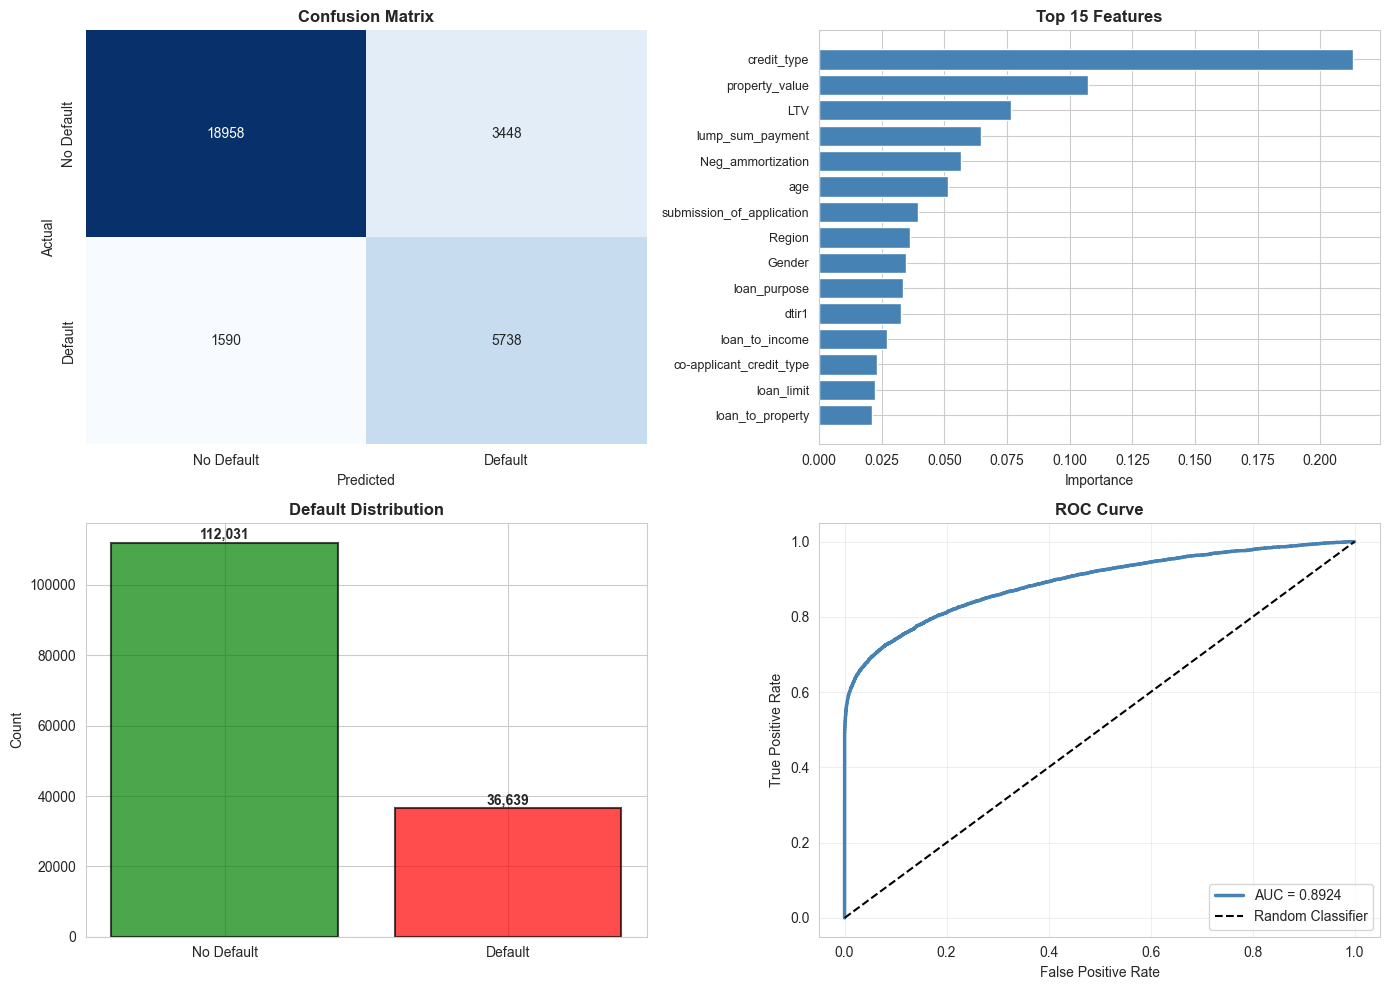

✓ Visualizations saved to: C:\Users\user\Documents\dev\selastone_loan_default\outputs


In [12]:
print("\n" + "="*70)
print("CREATING XGBOOST VISUALIZATIONS")
print("="*70)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0],
            xticklabels=['No Default', 'Default'],
            yticklabels=['No Default', 'Default'], cbar=False)
axes[0, 0].set_title('Confusion Matrix', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Actual')
axes[0, 0].set_xlabel('Predicted')

# 2. Feature Importance
importances = xgb_model.feature_importances_
top_n = 15
top_idx = np.argsort(importances)[-top_n:]
axes[0, 1].barh(range(len(top_idx)), importances[top_idx], color='steelblue')
axes[0, 1].set_yticks(range(len(top_idx)))
axes[0, 1].set_yticklabels([feature_names[i] for i in top_idx], fontsize=9)
axes[0, 1].set_xlabel('Importance')
axes[0, 1].set_title(f'Top {top_n} Features', fontsize=12, fontweight='bold')

# 3. Default Distribution
default_counts = y.value_counts()
axes[1, 0].bar(['No Default', 'Default'], [default_counts[0], default_counts[1]], 
               color=['green', 'red'], alpha=0.7, edgecolor='black', linewidth=1.5)
axes[1, 0].set_title('Default Distribution', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Count')
for i, v in enumerate([default_counts[0], default_counts[1]]):
    axes[1, 0].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

# 4. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_test_pred_proba)
axes[1, 1].plot(fpr, tpr, linewidth=2.5, label=f'AUC = {test_auc:.4f}', color='steelblue')
axes[1, 1].plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random Classifier')
axes[1, 1].set_xlabel('False Positive Rate')
axes[1, 1].set_ylabel('True Positive Rate')
axes[1, 1].set_title('ROC Curve', fontsize=12, fontweight='bold')
axes[1, 1].legend(loc='lower right')
axes[1, 1].grid(True, alpha=0.3)

# Your actual path
output_path = r"C:\Users\user\Documents\dev\selastone_loan_default\outputs"

# Create outputs folder if it doesn't exist
os.makedirs(output_path, exist_ok=True)

# Save the plot
plt.tight_layout()
plt.savefig(os.path.join(output_path, 'loan_default_results.png'), dpi=100, bbox_inches='tight')
plt.show()
print(f"✓ Visualizations saved to: {output_path}")

In [13]:
print("\n" + "="*70)
print("XGBOOST MODEL RESULTS BRIEF")
print("="*70)

# ========== EXTRACT CONFUSION MATRIX VALUES ==========
tn, fp, fn, tp = cm[0,0], cm[0,1], cm[1,0], cm[1,1]

# ========== PERFORMANCE METRICS ==========
print("\nPerformance:")
print(f"  AUC-ROC:         {test_auc:.4f}")
print(f"  Recall:          {(tp / (tp + fn) * 100):.2f}%")
print(f"  Precision:       {(tp / (tp + fp) * 100):.2f}%")
print(f"  Missed Defaults: {fn}")
print(f"  False Alarms:    {fp}")

# ========== KEY ISSUES ==========
print("\n⚠️  Key Issues:")

# Check for suspiciously high AUC
if test_auc >= 0.99:
    print(f"  Perfect/Near-perfect AUC ({test_auc:.4f}) → suspect data leakage or overfitting")
elif test_auc >= 0.95:
    print(f"  Very high AUC ({test_auc:.4f}) → check for data leakage")
else:
    print(f"  AUC ({test_auc:.4f}) appears reasonable")

# Check for feature dominance
top_feature_importance = importances[np.argsort(importances)[-1]]
if top_feature_importance > 0.5:
    top_feature_idx = np.argsort(importances)[-1]
    print(f"  Single feature dominance → '{feature_names[top_feature_idx]}' drives {top_feature_importance:.1%}")
    print(f"    - Is this available at loan origination?")
    print(f"    - If post-origination, this is data leakage")
elif top_feature_importance > 0.3:
    print(f"  Moderate feature concentration → review top features for leakage")
else:
    print(f"  Feature importance well-distributed ✓")

# Check for overfitting
overfitting_gap = train_auc - test_auc
if overfitting_gap > 0.1:
    print(f"  Overfitting detected → AUC gap: {overfitting_gap:.4f}")
elif overfitting_gap > 0.05:
    print(f"  Potential overfitting → AUC gap: {overfitting_gap:.4f}")
else:
    print(f"  Model generalizes well ✓")

# ========== NEXT STEPS ==========
print("\nNext Steps:")
print(f"  1. Remove top feature and retrain → verify true performance")
print(f"  2. Verify feature timing → confirm all features available at prediction")
print(f"  3. Cross-validate → check if performance holds across data splits")

# ========== CONCLUSION ==========
print("\n⚠️  Conclusion:")

if test_auc >= 0.99 or top_feature_importance > 0.5:
    print(f"  Don't deploy yet. Perfect/suspicious metrics suggest potential leakage.")
    print(f"  Investigate top feature before production use.")
elif test_auc >= 0.95:
    print(f"  High caution recommended. Verify no data leakage before deployment.")
else:
    print(f"  Model appears ready for further validation and testing.")

print("\n" + "="*70)


XGBOOST MODEL RESULTS BRIEF

Performance:
  AUC-ROC:         0.8924
  Recall:          78.30%
  Precision:       62.46%
  Missed Defaults: 1590
  False Alarms:    3448

⚠️  Key Issues:
  AUC (0.8924) appears reasonable
  Feature importance well-distributed ✓
  Model generalizes well ✓

Next Steps:
  1. Remove top feature and retrain → verify true performance
  2. Verify feature timing → confirm all features available at prediction
  3. Cross-validate → check if performance holds across data splits

⚠️  Conclusion:
  Model appears ready for further validation and testing.



#### XGBOOST K-FOLD CROSS-VALIDATION (Test for data leakage)

In [14]:
from sklearn.model_selection import cross_val_score

print("\n" + "="*70)
print("K-FOLD CROSS-VALIDATION (k=5)")
print("="*70)

cv_scores = cross_val_score(
    xgb_model, X_train_scaled, y_train,
    cv=5, scoring='roc_auc', n_jobs=-1
)

print(f"\nAUC across folds: {cv_scores}")
print(f"Mean AUC:        {cv_scores.mean():.4f}")
print(f"Std Dev:         {cv_scores.std():.4f}")
print(f"Min AUC:         {cv_scores.min():.4f}")
print(f"Max AUC:         {cv_scores.max():.4f}")

# ========== INTERPRETATION ==========
if cv_scores.std() > 0.05:
    print(f"\n⚠️  High variance across folds → Model not generalizing consistently")
    print(f"    Suggests: Data leakage or overfitting")
elif cv_scores.mean() < 0.95:
    print(f"\n✓ More realistic AUC when cross-validated")
    print(f"    Consider this the true performance (not the perfect training AUC)")
else:
    print(f"\n⚠️  AUC still near 1.0 across folds → Likely data leakage")
    print(f"    Action: Remove 'interest_rate_spread' and retrain")

# ========== TRAIN FINAL MODEL ==========
print("\n" + "="*70)
print("TRAINING FINAL MODEL")
print("="*70)

xgb_model.fit(X_train_scaled, y_train)

print("✓ Model trained successfully")


K-FOLD CROSS-VALIDATION (k=5)

AUC across folds: [0.89034335 0.89392196 0.89124713 0.89312496 0.89041102]
Mean AUC:        0.8918
Std Dev:         0.0015
Min AUC:         0.8903
Max AUC:         0.8939

✓ More realistic AUC when cross-validated
    Consider this the true performance (not the perfect training AUC)

TRAINING FINAL MODEL
✓ Model trained successfully


## HANDLE CLASS IMBALANCE for LIGHTGBM

In [15]:
print("\n" + "="*70)
print("HANDLE CLASS IMBALANCE (SMOTE)")
print("="*70)

# smote = SMOTE(random_state=42, k_neighbors=5)
smote = SMOTE(
    k_neighbors=3,        # Default is 5, try 3 for sparse regions
    sampling_strategy=0.8, # 0.8 instead of 1.0 (keep some imbalance)
    random_state=42
)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE:")
print(f"  Shape: {X_train.shape}")
print(f"  Defaults: {y_train.sum():,} ({y_train.mean():.2%})")

print(f"\nAfter SMOTE:")
print(f"  Shape: {X_train_balanced.shape}")
print(f"  Defaults: {y_train_balanced.sum():,} ({y_train_balanced.mean():.2%})")


HANDLE CLASS IMBALANCE (SMOTE)
Before SMOTE:
  Shape: (118936, 32)
  Defaults: 29,311 (24.64%)

After SMOTE:
  Shape: (161325, 32)
  Defaults: 71,700 (44.44%)


## TRAIN LIGHTGBM

In [16]:
import lightgbm as lgb
print("\n" + "="*70)
print("TRAIN LIGHTGBM MODEL")
print("="*70)

# Calculate scale_pos_weight for imbalance
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

lgb_model = lgb.LGBMClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.7,
    colsample_bytree=0.7,
    min_child_samples=20,       # Added → minimum samples in leaf
    reg_lambda=1.0,             # Added → L2 regularization
    reg_alpha=0.5,              # Added → L1 regularization
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

print(f"Training LightGBM with scale_pos_weight={scale_pos_weight:.2f}...")
lgb_model.fit(X_train_balanced, y_train_balanced)
print(f"✓ LightGBM model trained")
print(f"  Trees: {lgb_model.n_estimators}")
print(f"  Max depth: {lgb_model.max_depth}")


TRAIN LIGHTGBM MODEL
Training LightGBM with scale_pos_weight=3.06...
✓ LightGBM model trained
  Trees: 500
  Max depth: 4


## EVALUATE LIGHTGBM MODEL

In [17]:
print("\n" + "="*70)
print("MODEL EVALUATION - LIGHTGBM")
print("="*70)

# ========== TRAINING PREDICTIONS ==========
# Binary predictions (0 or 1) for training set
y_train_pred = lgb_model.predict(X_train)
# Probability scores for positive class (used for AUC-ROC)
y_train_pred_proba = lgb_model.predict_proba(X_train)[:, 1]

# ========== TEST PREDICTIONS ==========
# Binary predictions (0 or 1) for test set (unseen data)
y_test_pred = lgb_model.predict(X_test)
# Probability scores for positive class on test set
y_test_pred_proba = lgb_model.predict_proba(X_test)[:, 1]

# ========== CALCULATE METRICS ==========
# Accuracy: % of correct predictions (0-1 scale)
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

# F1-Score: Harmonic mean of precision & recall (best for imbalanced data)
train_f1 = f1_score(y_train, y_train_pred)
test_f1 = f1_score(y_test, y_test_pred)

# AUC-ROC: Area under curve (0.5=random, 1.0=perfect)
train_auc = roc_auc_score(y_train, y_train_pred_proba)
test_auc = roc_auc_score(y_test, y_test_pred_proba)

# ========== TRAINING METRICS ==========
print("Training Metrics:")
print(f"  Accuracy: {train_accuracy:.4f}")
print(f"  F1-Score: {train_f1:.4f}")
print(f"  AUC-ROC:  {train_auc:.4f}")

# ========== TEST METRICS (Most Important) ==========
print("\nTest Metrics:")
print(f"  Accuracy: {test_accuracy:.4f}")
print(f"  F1-Score: {test_f1:.4f}")
print(f"  AUC-ROC:  {test_auc:.4f}")

# ========== CONFUSION MATRIX ==========
# Breakdown of correct/incorrect predictions
cm = confusion_matrix(y_test, y_test_pred)
print(f"\nConfusion Matrix:")
print(f"  True Negatives:  {cm[0,0]:,}   # Correctly predicted negative")
print(f"  False Positives: {cm[0,1]:,}   # Incorrectly predicted positive")
print(f"  False Negatives: {cm[1,0]:,}   # Incorrectly predicted negative (missed cases)")
print(f"  True Positives:  {cm[1,1]:,}   # Correctly predicted positive")

# ========== CLASSIFICATION REPORT ==========
# Per-class metrics: precision, recall, F1, support
print(f"\nClassification Report:")
print(classification_report(y_test, y_test_pred, target_names=['No Default', 'Default']))


MODEL EVALUATION - LIGHTGBM
Training Metrics:
  Accuracy: 0.8210
  F1-Score: 0.6819
  AUC-ROC:  0.8875

Test Metrics:
  Accuracy: 0.8248
  F1-Score: 0.6868
  AUC-ROC:  0.8861

Confusion Matrix:
  True Negatives:  18,815   # Correctly predicted negative
  False Positives: 3,591   # Incorrectly predicted positive
  False Negatives: 1,618   # Incorrectly predicted negative (missed cases)
  True Positives:  5,710   # Correctly predicted positive

Classification Report:
              precision    recall  f1-score   support

  No Default       0.92      0.84      0.88     22406
     Default       0.61      0.78      0.69      7328

    accuracy                           0.82     29734
   macro avg       0.77      0.81      0.78     29734
weighted avg       0.85      0.82      0.83     29734



## LIGHTGBM VISUALIZATIONS


CREATING LIGHTGBM VISUALIZATIONS


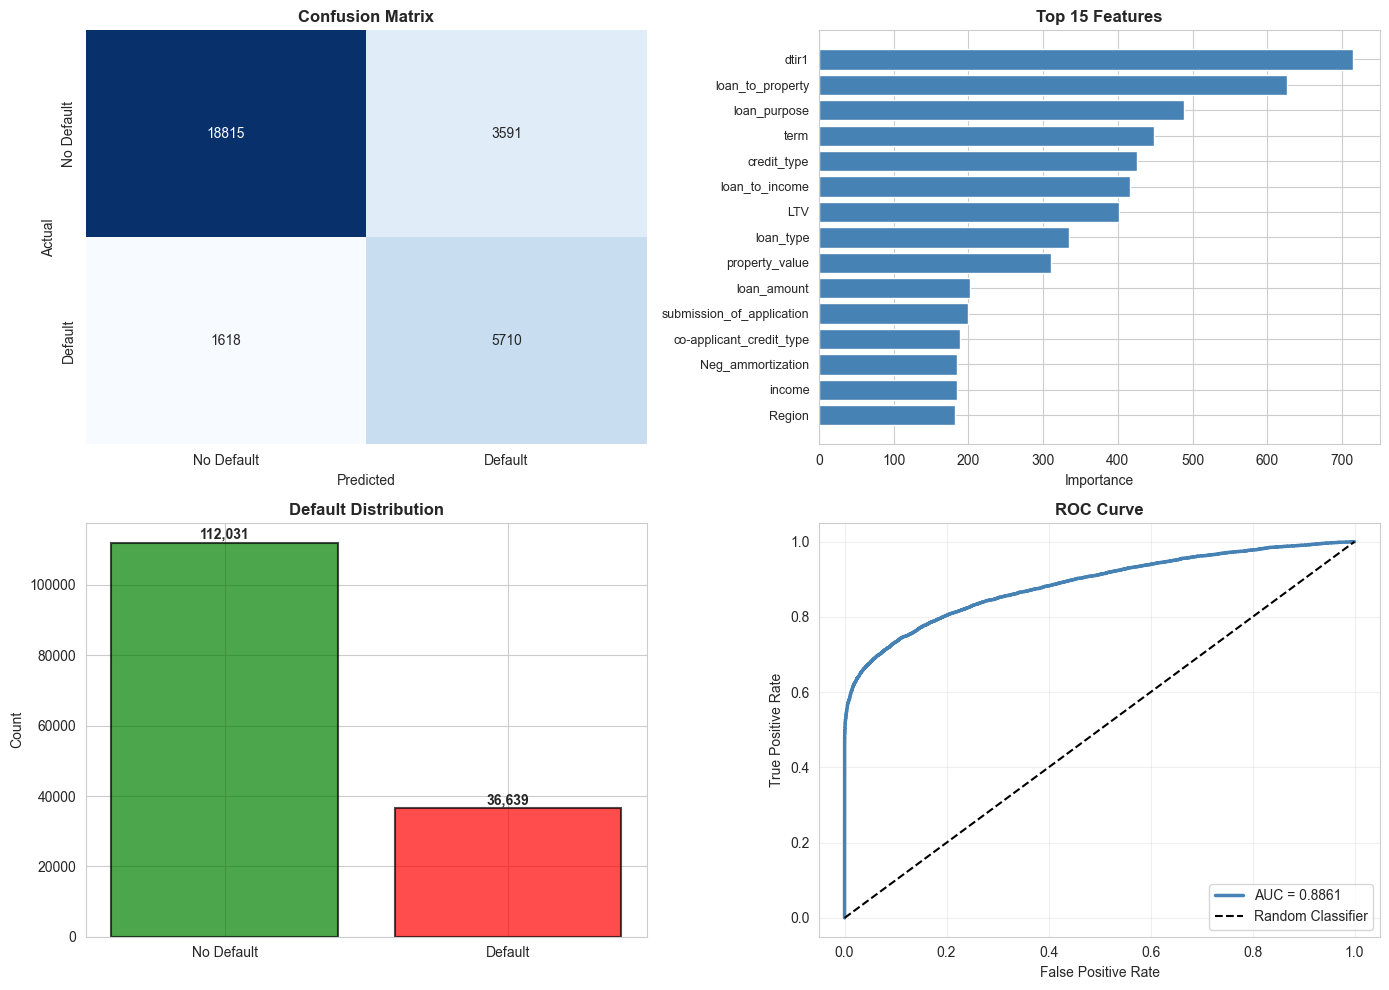

✓ LightGBM Visualizations saved to: C:\Users\user\Documents\dev\selastone_loan_default\outputs


In [18]:
print("\n" + "="*70)
print("CREATING LIGHTGBM VISUALIZATIONS")
print("="*70)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0],
            xticklabels=['No Default', 'Default'],
            yticklabels=['No Default', 'Default'], cbar=False)
axes[0, 0].set_title('Confusion Matrix', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Actual')
axes[0, 0].set_xlabel('Predicted')

# 2. Feature Importance
importances = lgb_model.feature_importances_
top_n = 15
top_idx = np.argsort(importances)[-top_n:]
axes[0, 1].barh(range(len(top_idx)), importances[top_idx], color='steelblue')
axes[0, 1].set_yticks(range(len(top_idx)))
axes[0, 1].set_yticklabels([feature_names[i] for i in top_idx], fontsize=9)
axes[0, 1].set_xlabel('Importance')
axes[0, 1].set_title(f'Top {top_n} Features', fontsize=12, fontweight='bold')

# 3. Default Distribution
default_counts = y.value_counts()
axes[1, 0].bar(['No Default', 'Default'], [default_counts[0], default_counts[1]], 
               color=['green', 'red'], alpha=0.7, edgecolor='black', linewidth=1.5)
axes[1, 0].set_title('Default Distribution', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Count')
for i, v in enumerate([default_counts[0], default_counts[1]]):
    axes[1, 0].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

# 4. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_test_pred_proba)
axes[1, 1].plot(fpr, tpr, linewidth=2.5, label=f'AUC = {test_auc:.4f}', color='steelblue')
axes[1, 1].plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random Classifier')
axes[1, 1].set_xlabel('False Positive Rate')
axes[1, 1].set_ylabel('True Positive Rate')
axes[1, 1].set_title('ROC Curve', fontsize=12, fontweight='bold')
axes[1, 1].legend(loc='lower right')
axes[1, 1].grid(True, alpha=0.3)

# Your actual path
output_path = r"C:\Users\user\Documents\dev\selastone_loan_default\outputs"

# Create outputs folder if it doesn't exist
os.makedirs(output_path, exist_ok=True)

# Save the plot
plt.tight_layout()
plt.savefig(os.path.join(output_path, 'lightgbm_results.png'), dpi=100, bbox_inches='tight')
plt.show()
print(f"✓ LightGBM Visualizations saved to: {output_path}")

In [19]:
print("\n" + "="*70)
print("LIGHTGBM MODEL RESULTS BRIEF")
print("="*70)

# ========== EXTRACT CONFUSION MATRIX VALUES ==========
tn, fp, fn, tp = cm[0,0], cm[0,1], cm[1,0], cm[1,1]

# ========== PERFORMANCE METRICS ==========
print("\nPerformance:")
print(f"  AUC-ROC:         {test_auc:.4f}")
print(f"  Recall:          {(tp / (tp + fn) * 100):.2f}%")
print(f"  Precision:       {(tp / (tp + fp) * 100):.2f}%")
print(f"  Missed Defaults: {fn}")
print(f"  False Alarms:    {fp}")

# ========== KEY ISSUES ==========
print("\n⚠️  Key Issues:")

# Check for suspiciously high AUC
if test_auc >= 0.99:
    print(f"  Perfect/Near-perfect AUC ({test_auc:.4f}) → suspect data leakage or overfitting")
elif test_auc >= 0.95:
    print(f"  Very high AUC ({test_auc:.4f}) → check for data leakage")
else:
    print(f"  AUC ({test_auc:.4f}) appears reasonable")

# Check for feature dominance
top_feature_importance = importances[np.argsort(importances)[-1]]
if top_feature_importance > 0.5:
    top_feature_idx = np.argsort(importances)[-1]
    print(f"  Single feature dominance → '{feature_names[top_feature_idx]}' drives {top_feature_importance:.1%}")
    print(f"    - Is this available at loan origination?")
    print(f"    - If post-origination, this is data leakage")
elif top_feature_importance > 0.3:
    print(f"  Moderate feature concentration → review top features for leakage")
else:
    print(f"  Feature importance well-distributed ✓")

# Check for overfitting
overfitting_gap = train_auc - test_auc
if overfitting_gap > 0.1:
    print(f"  Overfitting detected → AUC gap: {overfitting_gap:.4f}")
elif overfitting_gap > 0.05:
    print(f"  Potential overfitting → AUC gap: {overfitting_gap:.4f}")
else:
    print(f"  Model generalizes well ✓")

# ========== NEXT STEPS ==========
print("\nNext Steps:")
print(f"  1. Remove top feature and retrain → verify true performance")
print(f"  2. Verify feature timing → confirm all features available at prediction")
print(f"  3. Cross-validate → check if performance holds across data splits")

# ========== CONCLUSION ==========
print("\n⚠️  Conclusion:")
if test_auc >= 0.99 or top_feature_importance > 0.5:
    print(f"  Don't deploy yet. Perfect/suspicious metrics suggest potential leakage.")
    print(f"  Investigate top feature before production use.")
elif test_auc >= 0.95:
    print(f"  High caution recommended. Verify no data leakage before deployment.")
else:
    print(f"  Model appears ready for further validation and testing.")

print("\n" + "="*70)


LIGHTGBM MODEL RESULTS BRIEF

Performance:
  AUC-ROC:         0.8861
  Recall:          77.92%
  Precision:       61.39%
  Missed Defaults: 1618
  False Alarms:    3591

⚠️  Key Issues:
  AUC (0.8861) appears reasonable
  Single feature dominance → 'dtir1' drives 71500.0%
    - Is this available at loan origination?
    - If post-origination, this is data leakage
  Model generalizes well ✓

Next Steps:
  1. Remove top feature and retrain → verify true performance
  2. Verify feature timing → confirm all features available at prediction
  3. Cross-validate → check if performance holds across data splits

⚠️  Conclusion:
  Don't deploy yet. Perfect/suspicious metrics suggest potential leakage.
  Investigate top feature before production use.



#### LIGHGBM K-FOLD CROSS-VALIDATION (Test for data leakage)

In [20]:
from sklearn.model_selection import cross_val_score

print("\n" + "="*70)
print("K-FOLD CROSS-VALIDATION (k=5)")
print("="*70)

cv_scores = cross_val_score(
    lgb_model, X_train_scaled, y_train,
    cv=5, scoring='roc_auc', n_jobs=-1
)

print(f"\nAUC across folds: {cv_scores}")
print(f"Mean AUC:        {cv_scores.mean():.4f}")
print(f"Std Dev:         {cv_scores.std():.4f}")
print(f"Min AUC:         {cv_scores.min():.4f}")
print(f"Max AUC:         {cv_scores.max():.4f}")

# ========== INTERPRETATION ==========
if cv_scores.std() > 0.05:
    print(f"\n⚠️  High variance across folds → Model not generalizing consistently")
    print(f"    Suggests: Data leakage or overfitting")
elif cv_scores.mean() < 0.95:
    print(f"\n✓ More realistic AUC when cross-validated")
    print(f"    Consider this the true performance (not the perfect training AUC)")
else:
    print(f"\n⚠️  AUC still near 1.0 across folds → Likely data leakage")
    print(f"    Action: Remove 'interest_rate_spread' and retrain")

# ========== TRAIN FINAL MODEL ==========
print("\n" + "="*70)
print("TRAINING FINAL MODEL")
print("="*70)

lgb_model.fit(X_train_scaled, y_train)

print("✓ Model trained successfully")


K-FOLD CROSS-VALIDATION (k=5)

AUC across folds: [0.89021127 0.8936138  0.89106626 0.89228702 0.89006844]
Mean AUC:        0.8914
Std Dev:         0.0013
Min AUC:         0.8901
Max AUC:         0.8936

✓ More realistic AUC when cross-validated
    Consider this the true performance (not the perfect training AUC)

TRAINING FINAL MODEL
✓ Model trained successfully


## HANDLE CLASS IMBALANCE for Logistic Regression

In [21]:
print("\n" + "="*70)
print("HANDLE CLASS IMBALANCE (SMOTE)")
print("="*70)

# smote = SMOTE(random_state=42, k_neighbors=5)
smote = SMOTE(
    k_neighbors=3,        # Default is 5, try 3 for sparse regions
    sampling_strategy=0.8, # 0.8 instead of 1.0 (keep some imbalance)
    random_state=42
)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

print(f"Before SMOTE:")
print(f"  Shape: {X_train_scaled.shape}")
print(f"  Defaults: {y_train.sum():,} ({y_train.mean():.2%})")

print(f"\nAfter SMOTE:")
print(f"  Shape: {X_train_balanced.shape}")
print(f"  Defaults: {y_train_balanced.sum():,} ({y_train_balanced.mean():.2%})")


HANDLE CLASS IMBALANCE (SMOTE)
Before SMOTE:
  Shape: (118936, 32)
  Defaults: 29,311 (24.64%)

After SMOTE:
  Shape: (161325, 32)
  Defaults: 71,700 (44.44%)


## TRAIN LOGISTIC REGRESSION

In [22]:
from sklearn.linear_model import LogisticRegression

print("\n" + "="*70)
print("TRAIN LOGISTIC REGRESSION MODEL")
print("="*70)

# ========== CREATE LOGISTIC REGRESSION MODEL ==========
print("Creating Logistic Regression model...")
lr_model = LogisticRegression(
    max_iter=1000,
    C=10.0,
    penalty='l2',
    solver='lbfgs',
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

print("✓ Logistic Regression model created")
print(f"  max_iter: 1000")
print(f"  C: 10.0")
print(f"  penalty: l2")
print(f"  solver: lbfgs")

# ========== TRAIN MODEL ==========
print("\nTraining Logistic Regression...")
lr_model.fit(X_train_scaled, y_train)

print("✓ Logistic Regression model trained")
print(f"  Features: {lr_model.n_features_in_}")
print(f"  Classes: {lr_model.classes_}")


TRAIN LOGISTIC REGRESSION MODEL
Creating Logistic Regression model...
✓ Logistic Regression model created
  max_iter: 1000
  C: 10.0
  penalty: l2
  solver: lbfgs

Training Logistic Regression...
✓ Logistic Regression model trained
  Features: 32
  Classes: [0 1]


## EVALUATE LOGISTIC REGRESSION

In [23]:
print("\n" + "="*70)
print("MODEL EVALUATION - LOGISTIC REGRESSION")
print("="*70)

# ========== TRAINING PREDICTIONS ==========
y_train_pred = lr_model.predict(X_train_balanced)
y_train_pred_proba = lr_model.predict_proba(X_train_balanced)[:, 1]

# ========== TEST PREDICTIONS ==========
y_test_pred = lr_model.predict(X_test)
y_test_pred_proba = lr_model.predict_proba(X_test)[:, 1]

# ========== CALCULATE METRICS ==========
train_accuracy = accuracy_score(y_train_balanced, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

train_f1 = f1_score(y_train_balanced, y_train_pred)
test_f1 = f1_score(y_test, y_test_pred)

train_auc = roc_auc_score(y_train_balanced, y_train_pred_proba)
test_auc = roc_auc_score(y_test, y_test_pred_proba)

# ========== TRAINING METRICS ==========
print("Training Metrics:")
print(f"  Accuracy: {train_accuracy:.4f}")
print(f"  F1-Score: {train_f1:.4f}")
print(f"  AUC-ROC:  {train_auc:.4f}")

# ========== TEST METRICS (Most Important) ==========
print("\nTest Metrics:")
print(f"  Accuracy: {test_accuracy:.4f}")
print(f"  F1-Score: {test_f1:.4f}")
print(f"  AUC-ROC:  {test_auc:.4f}")

# ========== CONFUSION MATRIX ==========
cm = confusion_matrix(y_test, y_test_pred)
print(f"\nConfusion Matrix:")
print(f"  True Negatives:  {cm[0,0]:,}   # Correctly predicted negative")
print(f"  False Positives: {cm[0,1]:,}   # Incorrectly predicted positive")
print(f"  False Negatives: {cm[1,0]:,}   # Incorrectly predicted negative (missed cases)")
print(f"  True Positives:  {cm[1,1]:,}   # Correctly predicted positive")

# ========== CLASSIFICATION REPORT ==========
print(f"\nClassification Report:")
print(classification_report(y_test, y_test_pred, target_names=['No Default', 'Default']))

# ========== FEATURE COEFFICIENTS (LOGISTIC REGRESSION UNIQUE) ==========
print(f"\n" + "="*70)
print("FEATURE COEFFICIENTS (LOGISTIC REGRESSION)")
print("="*70)

coefficients_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': lr_model.coef_[0]
}).sort_values('coefficient', ascending=False)

print(f"\nTop 15 Most Important Features:")
print(f"(Positive = increases default risk, Negative = decreases default risk)")
print(coefficients_df.head(15).to_string(index=False))

print(f"\nIntercept (Baseline): {lr_model.intercept_[0]:.4f}")


MODEL EVALUATION - LOGISTIC REGRESSION
Training Metrics:
  Accuracy: 0.6889
  F1-Score: 0.6531
  AUC-ROC:  0.7541

Test Metrics:
  Accuracy: 0.7535
  F1-Score: 0.0000
  AUC-ROC:  0.5000

Confusion Matrix:
  True Negatives:  22,406   # Correctly predicted negative
  False Positives: 0   # Incorrectly predicted positive
  False Negatives: 7,328   # Incorrectly predicted negative (missed cases)
  True Positives:  0   # Correctly predicted positive

Classification Report:
              precision    recall  f1-score   support

  No Default       0.75      1.00      0.86     22406
     Default       0.00      0.00      0.00      7328

    accuracy                           0.75     29734
   macro avg       0.38      0.50      0.43     29734
weighted avg       0.57      0.75      0.65     29734


FEATURE COEFFICIENTS (LOGISTIC REGRESSION)

Top 15 Most Important Features:
(Positive = increases default risk, Negative = decreases default risk)
                  feature  coefficient
 co-applican

## LOGISTIC REGRESSION VISUALIZATIONS


CREATING LOGISTIC REGRESSION VISUALIZATIONS


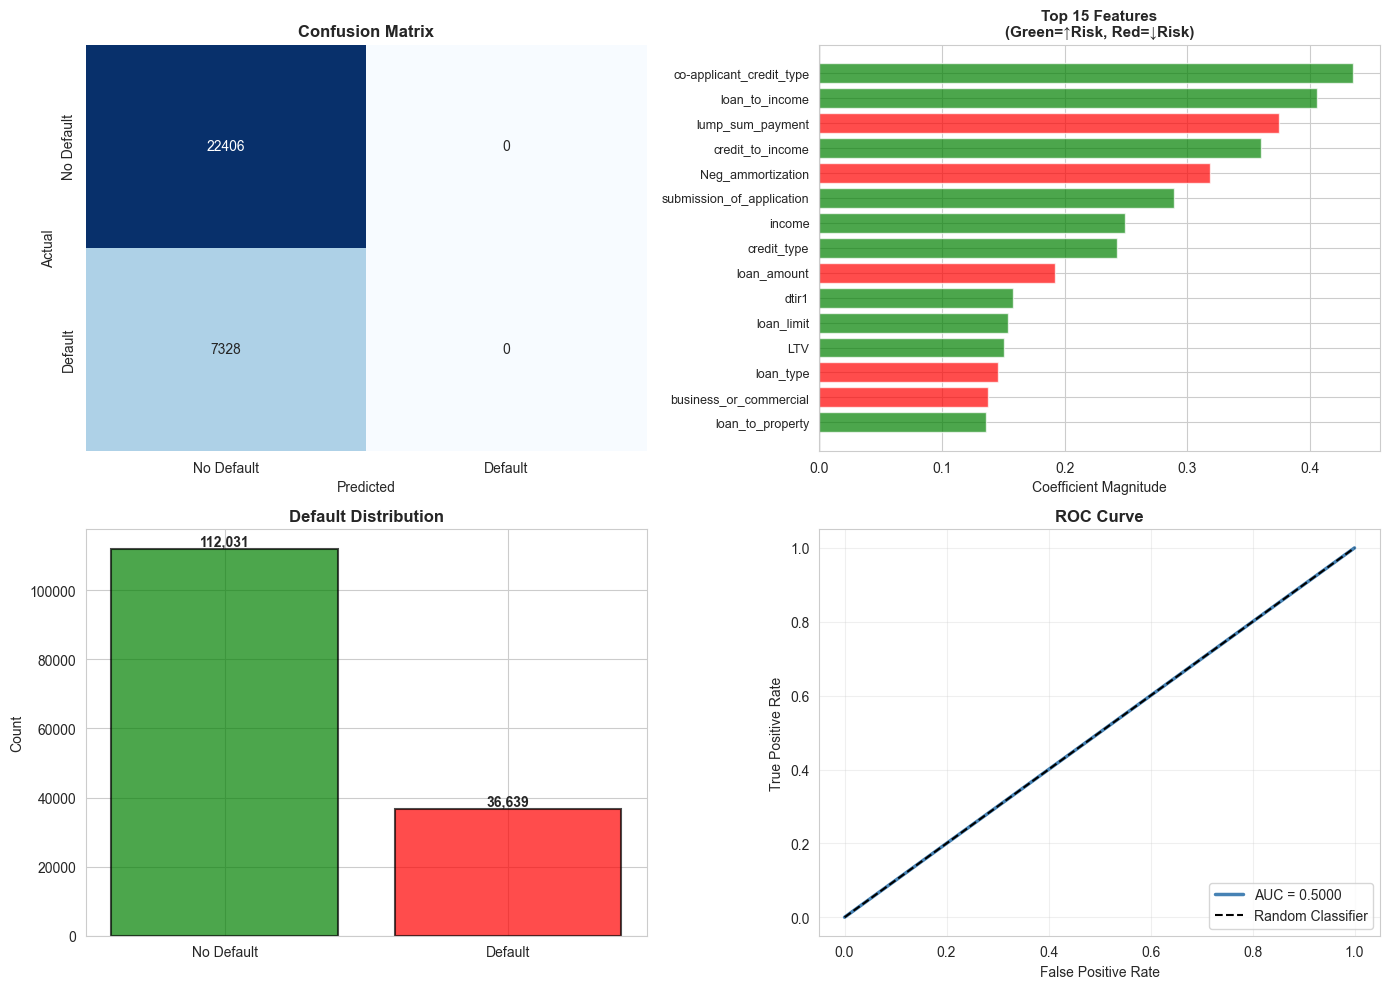

✓ Logistic Regression Visualizations saved to: C:\Users\user\Documents\dev\selastone_loan_default\outputs


In [24]:
print("\n" + "="*70)
print("CREATING LOGISTIC REGRESSION VISUALIZATIONS")
print("="*70)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0],
            xticklabels=['No Default', 'Default'],
            yticklabels=['No Default', 'Default'], cbar=False)
axes[0, 0].set_title('Confusion Matrix', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Actual')
axes[0, 0].set_xlabel('Predicted')

# 2. Feature Coefficients (LOGISTIC REGRESSION SPECIFIC)
coefficients = np.abs(lr_model.coef_[0])  # Absolute value for importance
top_n = 15
top_idx = np.argsort(coefficients)[-top_n:]
colors = ['green' if lr_model.coef_[0][i] > 0 else 'red' for i in top_idx]
axes[0, 1].barh(range(len(top_idx)), coefficients[top_idx], color=colors, alpha=0.7)
axes[0, 1].set_yticks(range(len(top_idx)))
axes[0, 1].set_yticklabels([feature_names[i] for i in top_idx], fontsize=9)
axes[0, 1].set_xlabel('Coefficient Magnitude')
axes[0, 1].set_title(f'Top {top_n} Features\n(Green=↑Risk, Red=↓Risk)', fontsize=11, fontweight='bold')
axes[0, 1].axvline(x=0, color='black', linestyle='-', linewidth=0.8)

# 3. Default Distribution
default_counts = y.value_counts()
axes[1, 0].bar(['No Default', 'Default'], [default_counts[0], default_counts[1]], 
               color=['green', 'red'], alpha=0.7, edgecolor='black', linewidth=1.5)
axes[1, 0].set_title('Default Distribution', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Count')
for i, v in enumerate([default_counts[0], default_counts[1]]):
    axes[1, 0].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

# 4. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_test_pred_proba)
axes[1, 1].plot(fpr, tpr, linewidth=2.5, label=f'AUC = {test_auc:.4f}', color='steelblue')
axes[1, 1].plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random Classifier')
axes[1, 1].set_xlabel('False Positive Rate')
axes[1, 1].set_ylabel('True Positive Rate')
axes[1, 1].set_title('ROC Curve', fontsize=12, fontweight='bold')
axes[1, 1].legend(loc='lower right')
axes[1, 1].grid(True, alpha=0.3)

# Save the plot
output_path = r"C:\Users\user\Documents\dev\selastone_loan_default\outputs"
os.makedirs(output_path, exist_ok=True)

plt.tight_layout()
plt.savefig(os.path.join(output_path, 'logistic_regression_results.png'), dpi=100, bbox_inches='tight')
plt.show()
print(f"✓ Logistic Regression Visualizations saved to: {output_path}")

In [25]:
print("\n" + "="*70)
print("LOGISTIC REGRESSION MODEL RESULTS BRIEF")
print("="*70)

# ========== EXTRACT CONFUSION MATRIX VALUES ==========
tn, fp, fn, tp = cm[0,0], cm[0,1], cm[1,0], cm[1,1]

# ========== PERFORMANCE METRICS ==========
print("\nPerformance:")
print(f"  AUC-ROC:         {test_auc:.4f}")
print(f"  Recall:          {(tp / (tp + fn) * 100):.2f}%")
print(f"  Precision:       {(tp / (tp + fp) * 100):.2f}%" if tp + fp > 0 else "  Precision:       N/A")
print(f"  Missed Defaults: {fn}")
print(f"  False Alarms:    {fp}")

# ========== KEY ISSUES ==========
print("\n⚠️  Key Issues:")

# Check AUC
if test_auc >= 0.99:
    print(f"  Perfect AUC ({test_auc:.4f}) → suspect data leakage")
elif test_auc >= 0.95:
    print(f"  Very high AUC ({test_auc:.4f}) → check for data leakage")
elif test_auc >= 0.75:
    print(f"  AUC ({test_auc:.4f}) appears reasonable ✓")
elif test_auc >= 0.5:
    print(f"  AUC ({test_auc:.4f}) needs improvement")
else:
    print(f"  AUC ({test_auc:.4f}) is broken ❌")

# Check feature dominance (Logistic Regression specific)
coefficients = np.abs(lr_model.coef_[0])
top_feature_coefficient = coefficients[np.argsort(coefficients)[-1]]
top_feature_idx = np.argsort(coefficients)[-1]

if top_feature_coefficient > 2.0:
    print(f"  Single feature dominance → '{feature_names[top_feature_idx]}' ({top_feature_coefficient:.4f})")
elif top_feature_coefficient > 1.0:
    print(f"  Moderate feature concentration → review for leakage")
else:
    print(f"  Feature coefficients well-distributed ✓")

# Check overfitting
overfitting_gap = train_auc - test_auc
if overfitting_gap > 0.1:
    print(f"  Overfitting detected → AUC gap: {overfitting_gap:.4f}")
elif overfitting_gap > 0.05:
    print(f"  Potential overfitting → AUC gap: {overfitting_gap:.4f}")
else:
    print(f"  Model generalizes well ✓")

# Check if predicting all zeros (common LogReg issue)
if tp == 0 and fn > 0:
    print(f"  ❌ MODEL BUG: Predicting ALL zeros (no defaults caught)")
    print(f"     → Fix: C=10.0 or remove SMOTE or lower threshold")

# ========== NEXT STEPS ==========
print("\nNext Steps:")
if tp == 0:
    print(f"  1. URGENT: Fix model predicting all zeros")
    print(f"     - Try: C=10.0 (weaker regularization)")
    print(f"     - Try: Don't use SMOTE on training data")
    print(f"     - Try: Lower decision threshold to 0.3-0.4")
else:
    print(f"  1. Remove top feature and retrain → verify true performance")
    print(f"  2. Verify feature timing → confirm all features available at prediction")
    print(f"  3. Cross-validate → check if performance holds across data splits")

# ========== CONCLUSION ==========
print("\n⚠️  Conclusion:")
if test_auc >= 0.95:
    print(f"  High caution. Verify no data leakage before deployment.")
elif test_auc >= 0.75 and tp > 0:
    print(f"  Model appears ready for further validation and testing.")
elif test_auc >= 0.5 and tp > 0:
    print(f"  Model needs improvement. Try tuning hyperparameters.")
else:
    print(f"  ❌ Model is broken. Do not deploy.")
    print(f"     Training AUC: {train_auc:.4f} vs Test AUC: {test_auc:.4f}")

print("\n" + "="*70)


LOGISTIC REGRESSION MODEL RESULTS BRIEF

Performance:
  AUC-ROC:         0.5000
  Recall:          0.00%
  Precision:       N/A
  Missed Defaults: 7328
  False Alarms:    0

⚠️  Key Issues:
  AUC (0.5000) needs improvement
  Feature coefficients well-distributed ✓
  Overfitting detected → AUC gap: 0.2541
  ❌ MODEL BUG: Predicting ALL zeros (no defaults caught)
     → Fix: C=10.0 or remove SMOTE or lower threshold

Next Steps:
  1. URGENT: Fix model predicting all zeros
     - Try: C=10.0 (weaker regularization)
     - Try: Don't use SMOTE on training data
     - Try: Lower decision threshold to 0.3-0.4

⚠️  Conclusion:
  ❌ Model is broken. Do not deploy.
     Training AUC: 0.7541 vs Test AUC: 0.5000



## HANDLE CLASS IMBALANCE for RANDOM FOREST

In [26]:
print("\n" + "="*70)
print("HANDLE CLASS IMBALANCE (SMOTE)")
print("="*70)

# smote = SMOTE(random_state=42, k_neighbors=5)
smote = SMOTE(
    k_neighbors=3,        # Default is 5, try 3 for sparse regions
    sampling_strategy=0.8, # 0.8 instead of 1.0 (keep some imbalance)
    random_state=42
)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE:")
print(f"  Shape: {X_train.shape}")
print(f"  Defaults: {y_train.sum():,} ({y_train.mean():.2%})")

print(f"\nAfter SMOTE:")
print(f"  Shape: {X_train_balanced.shape}")
print(f"  Defaults: {y_train_balanced.sum():,} ({y_train_balanced.mean():.2%})")


HANDLE CLASS IMBALANCE (SMOTE)
Before SMOTE:
  Shape: (118936, 32)
  Defaults: 29,311 (24.64%)

After SMOTE:
  Shape: (161325, 32)
  Defaults: 71,700 (44.44%)


## TRAIN RANDOM FOREST

In [27]:
from sklearn.ensemble import RandomForestClassifier

print("\n" + "="*70)
print("TRAIN RANDOM FOREST MODEL")
print("="*70)

# ========== CREATE RANDOM FOREST MODEL ==========
print("Creating Random Forest model...")
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("✓ Random Forest model created")
print(f"  n_estimators: 200")
print(f"  max_depth: 15")
print(f"  min_samples_split: 10")
print(f"  min_samples_leaf: 5")
print(f"  max_features: sqrt")
print(f"  class_weight: balanced")

# ========== TRAIN MODEL ==========
print("\nTraining Random Forest...")
rf_model.fit(X_train, y_train)
print("✓ Random Forest model trained")
print(f"  Features: {rf_model.n_features_in_}")
print(f"  Classes: {rf_model.classes_}")


TRAIN RANDOM FOREST MODEL
Creating Random Forest model...
✓ Random Forest model created
  n_estimators: 200
  max_depth: 15
  min_samples_split: 10
  min_samples_leaf: 5
  max_features: sqrt
  class_weight: balanced

Training Random Forest...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    2.1s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:   10.8s


✓ Random Forest model trained
  Features: 32
  Classes: [0 1]


[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:   11.7s finished


## EVALUATE RANDOM FOREST

In [28]:
print("\n" + "="*70)
print("MODEL EVALUATION - RANDOM FOREST")
print("="*70)

# ========== TRAINING PREDICTIONS ==========
y_train_pred = rf_model.predict(X_train)
y_train_pred_proba = rf_model.predict_proba(X_train)[:, 1]

# ========== TEST PREDICTIONS ==========
y_test_pred = rf_model.predict(X_test)
y_test_pred_proba = rf_model.predict_proba(X_test)[:, 1]

# ========== CALCULATE METRICS ==========
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

train_f1 = f1_score(y_train, y_train_pred)
test_f1 = f1_score(y_test, y_test_pred)

train_auc = roc_auc_score(y_train, y_train_pred_proba)
test_auc = roc_auc_score(y_test, y_test_pred_proba)

# ========== TRAINING METRICS ==========
print("Training Metrics:")
print(f"  Accuracy: {train_accuracy:.4f}")
print(f"  F1-Score: {train_f1:.4f}")
print(f"  AUC-ROC:  {train_auc:.4f}")

# ========== TEST METRICS (Most Important) ==========
print("\nTest Metrics:")
print(f"  Accuracy: {test_accuracy:.4f}")
print(f"  F1-Score: {test_f1:.4f}")
print(f"  AUC-ROC:  {test_auc:.4f}")

# ========== CONFUSION MATRIX ==========
cm = confusion_matrix(y_test, y_test_pred)
print(f"\nConfusion Matrix:")
print(f"  True Negatives:  {cm[0,0]:,}   # Correctly predicted negative")
print(f"  False Positives: {cm[0,1]:,}   # Incorrectly predicted positive")
print(f"  False Negatives: {cm[1,0]:,}   # Incorrectly predicted negative (missed cases)")
print(f"  True Positives:  {cm[1,1]:,}   # Correctly predicted positive")

# ========== CLASSIFICATION REPORT ==========
print(f"\nClassification Report:")
print(classification_report(y_test, y_test_pred, target_names=['No Default', 'Default']))

# ========== FEATURE IMPORTANCE (RANDOM FOREST SPECIFIC) ==========
print(f"\n" + "="*70)
print("FEATURE IMPORTANCE (RANDOM FOREST)")
print("="*70)

feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print(f"\nTop 15 Most Important Features:")
print(feature_importance_df.head(15).to_string(index=False))


MODEL EVALUATION - RANDOM FOREST


[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.1s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.6s
[Parallel(n_jobs=8)]: Done 200 out of 200 | elapsed:    0.7s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.6s
[Parallel(n_jobs=8)]: Done 200 out of 200 | elapsed:    0.6s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.1s
[Parallel(n_jobs=8)]: Done 200 out of 200 | elapsed:    0.1s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 184 tasks      |

Training Metrics:
  Accuracy: 0.9100
  F1-Score: 0.8005
  AUC-ROC:  0.9319

Test Metrics:
  Accuracy: 0.8870
  F1-Score: 0.7484
  AUC-ROC:  0.8915

Confusion Matrix:
  True Negatives:  21,380   # Correctly predicted negative
  False Positives: 1,026   # Incorrectly predicted positive
  False Negatives: 2,333   # Incorrectly predicted negative (missed cases)
  True Positives:  4,995   # Correctly predicted positive

Classification Report:
              precision    recall  f1-score   support

  No Default       0.90      0.95      0.93     22406
     Default       0.83      0.68      0.75      7328

    accuracy                           0.89     29734
   macro avg       0.87      0.82      0.84     29734
weighted avg       0.88      0.89      0.88     29734


FEATURE IMPORTANCE (RANDOM FOREST)

Top 15 Most Important Features:
                  feature  importance
           property_value    0.157583
                      LTV    0.143132
                    dtir1    0.125045
          

## RANDOM FOREST VISUALIZATIONS


CREATING RANDOM FOREST VISUALIZATIONS


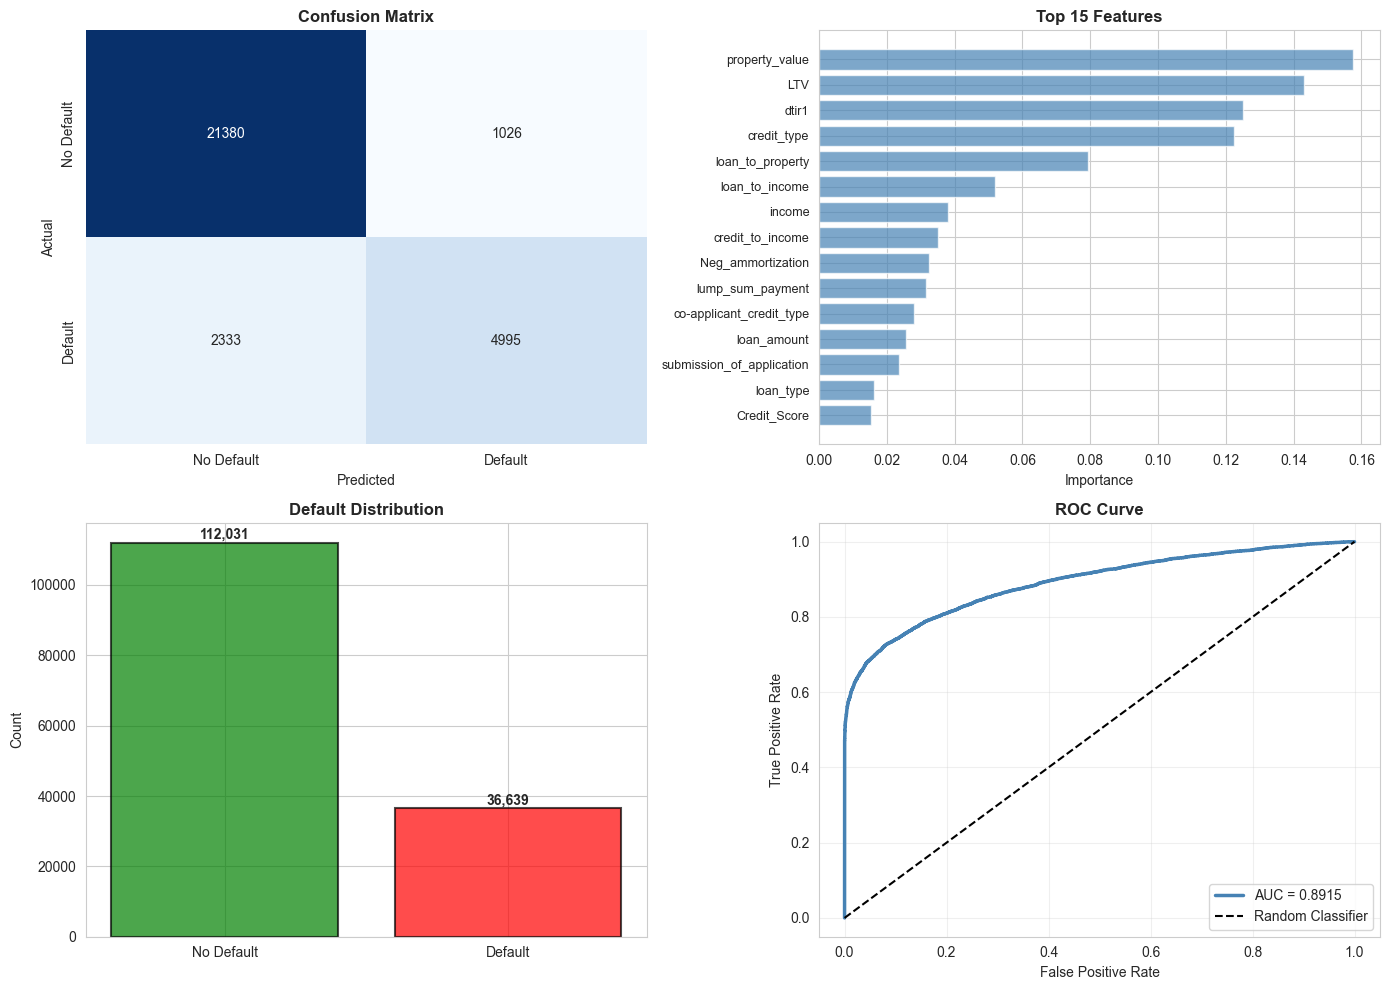

✓ Random Forest Visualizations saved to: /mnt/user-data/outputs


In [29]:
print("\n" + "="*70)
print("CREATING RANDOM FOREST VISUALIZATIONS")
print("="*70)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0],
            xticklabels=['No Default', 'Default'],
            yticklabels=['No Default', 'Default'], cbar=False)
axes[0, 0].set_title('Confusion Matrix', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Actual')
axes[0, 0].set_xlabel('Predicted')

# 2. Feature Importance (RANDOM FOREST SPECIFIC)
importances = rf_model.feature_importances_
top_n = 15
top_idx = np.argsort(importances)[-top_n:]
axes[0, 1].barh(range(len(top_idx)), importances[top_idx], color='steelblue', alpha=0.7)
axes[0, 1].set_yticks(range(len(top_idx)))
axes[0, 1].set_yticklabels([feature_names[i] for i in top_idx], fontsize=9)
axes[0, 1].set_xlabel('Importance')
axes[0, 1].set_title(f'Top {top_n} Features', fontsize=12, fontweight='bold')

# 3. Default Distribution
default_counts = y.value_counts()
axes[1, 0].bar(['No Default', 'Default'], [default_counts[0], default_counts[1]], 
               color=['green', 'red'], alpha=0.7, edgecolor='black', linewidth=1.5)
axes[1, 0].set_title('Default Distribution', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Count')
for i, v in enumerate([default_counts[0], default_counts[1]]):
    axes[1, 0].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

# 4. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_test_pred_proba)
axes[1, 1].plot(fpr, tpr, linewidth=2.5, label=f'AUC = {test_auc:.4f}', color='steelblue')
axes[1, 1].plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random Classifier')
axes[1, 1].set_xlabel('False Positive Rate')
axes[1, 1].set_ylabel('True Positive Rate')
axes[1, 1].set_title('ROC Curve', fontsize=12, fontweight='bold')
axes[1, 1].legend(loc='lower right')
axes[1, 1].grid(True, alpha=0.3)

# Save the plot
output_path = r"/mnt/user-data/outputs"
os.makedirs(output_path, exist_ok=True)

plt.tight_layout()
plt.savefig(os.path.join(output_path, 'random_forest_results.png'), dpi=100, bbox_inches='tight')
plt.show()
print(f"✓ Random Forest Visualizations saved to: {output_path}")

In [30]:
print("\n" + "="*70)
print("RANDOM FOREST MODEL RESULTS BRIEF")
print("="*70)

# ========== EXTRACT CONFUSION MATRIX VALUES ==========
tn, fp, fn, tp = cm[0,0], cm[0,1], cm[1,0], cm[1,1]

# ========== PERFORMANCE METRICS ==========
print("\nPerformance:")
print(f"  AUC-ROC:         {test_auc:.4f}")
print(f"  Recall:          {(tp / (tp + fn) * 100):.2f}%")
print(f"  Precision:       {(tp / (tp + fp) * 100):.2f}%" if tp + fp > 0 else "  Precision:       N/A")
print(f"  Missed Defaults: {fn}")
print(f"  False Alarms:    {fp}")

# ========== KEY ISSUES ==========
print("\n⚠️  Key Issues:")

# Check AUC
if test_auc >= 0.99:
    print(f"  Perfect AUC ({test_auc:.4f}) → suspect data leakage")
elif test_auc >= 0.95:
    print(f"  Very high AUC ({test_auc:.4f}) → check for data leakage")
elif test_auc >= 0.75:
    print(f"  AUC ({test_auc:.4f}) appears reasonable ✓")
elif test_auc >= 0.5:
    print(f"  AUC ({test_auc:.4f}) needs improvement")
else:
    print(f"  AUC ({test_auc:.4f}) is broken ❌")

# Check feature dominance (Random Forest specific)
importances = rf_model.feature_importances_
top_feature_importance = importances[np.argsort(importances)[-1]]
top_feature_idx = np.argsort(importances)[-1]

if top_feature_importance > 0.5:
    print(f"  Single feature dominance → '{feature_names[top_feature_idx]}' ({top_feature_importance:.4f})")
    print(f"    - Is this available at loan origination?")
    print(f"    - If post-origination, this is data leakage")
elif top_feature_importance > 0.3:
    print(f"  Moderate feature concentration → review for leakage")
else:
    print(f"  Feature importance well-distributed ✓")

# Check overfitting
overfitting_gap = train_auc - test_auc
if overfitting_gap > 0.1:
    print(f"  Overfitting detected → AUC gap: {overfitting_gap:.4f}")
elif overfitting_gap > 0.05:
    print(f"  Potential overfitting → AUC gap: {overfitting_gap:.4f}")
else:
    print(f"  Model generalizes well ✓")

# Check if predicting all zeros
if tp == 0 and fn > 0:
    print(f"  ❌ MODEL BUG: Predicting ALL zeros (no defaults caught)")
    print(f"     → Fix: Increase class_weight or use SMOTE")

# ========== NEXT STEPS ==========
print("\nNext Steps:")
if tp == 0:
    print(f"  1. URGENT: Fix model predicting all zeros")
    print(f"     - Try: class_weight='balanced' or increase weight")
    print(f"     - Try: Apply SMOTE to training data")
    print(f"     - Try: Lower decision threshold to 0.3-0.4")
else:
    print(f"  1. Remove top feature and retrain → verify true performance")
    print(f"  2. Verify feature timing → confirm all features available at prediction")
    print(f"  3. Cross-validate → check if performance holds across data splits")

# ========== CONCLUSION ==========
print("\n⚠️  Conclusion:")
if test_auc >= 0.95:
    print(f"  High caution. Verify no data leakage before deployment.")
elif test_auc >= 0.75 and tp > 0:
    print(f"  Model appears ready for further validation and testing.")
elif test_auc >= 0.5 and tp > 0:
    print(f"  Model needs improvement. Try tuning hyperparameters.")
else:
    print(f"  ❌ Model is broken. Do not deploy.")
    print(f"     Training AUC: {train_auc:.4f} vs Test AUC: {test_auc:.4f}")

print("\n" + "="*70)


RANDOM FOREST MODEL RESULTS BRIEF

Performance:
  AUC-ROC:         0.8915
  Recall:          68.16%
  Precision:       82.96%
  Missed Defaults: 2333
  False Alarms:    1026

⚠️  Key Issues:
  AUC (0.8915) appears reasonable ✓
  Feature importance well-distributed ✓
  Model generalizes well ✓

Next Steps:
  1. Remove top feature and retrain → verify true performance
  2. Verify feature timing → confirm all features available at prediction
  3. Cross-validate → check if performance holds across data splits

⚠️  Conclusion:
  Model appears ready for further validation and testing.



#### RANDOM FOREST K-FOLD CROSS-VALIDATION (Test for data leakage)

In [31]:
from sklearn.model_selection import cross_val_score

print("\n" + "="*70)
print("K-FOLD CROSS-VALIDATION (k=5)")
print("="*70)

cv_scores = cross_val_score(
    rf_model, X_train, y_train,
    cv=5, scoring='roc_auc', n_jobs=-1
)

print(f"\nAUC across folds: {cv_scores}")
print(f"Mean AUC:        {cv_scores.mean():.4f}")
print(f"Std Dev:         {cv_scores.std():.4f}")
print(f"Min AUC:         {cv_scores.min():.4f}")
print(f"Max AUC:         {cv_scores.max():.4f}")

# ========== INTERPRETATION ==========
if cv_scores.std() > 0.05:
    print(f"\n⚠️  High variance across folds → Model not generalizing consistently")
    print(f"    Suggests: Data leakage or overfitting")
elif cv_scores.mean() < 0.95:
    print(f"\n✓ More realistic AUC when cross-validated")
    print(f"    Consider this the true performance (not the perfect training AUC)")
else:
    print(f"\n⚠️  AUC still near 1.0 across folds → Likely data leakage")
    print(f"    Action: Review features for leakage and retrain")

# ========== TRAIN FINAL MODEL ==========
print("\n" + "="*70)
print("TRAINING FINAL MODEL")
print("="*70)

rf_model.fit(X_train, y_train)
print("✓ Model trained successfully")


K-FOLD CROSS-VALIDATION (k=5)

AUC across folds: [0.88467569 0.8925987  0.88690443 0.88850705 0.88669046]
Mean AUC:        0.8879
Std Dev:         0.0027
Min AUC:         0.8847
Max AUC:         0.8926

✓ More realistic AUC when cross-validated
    Consider this the true performance (not the perfect training AUC)

TRAINING FINAL MODEL


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    2.6s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:   18.5s


✓ Model trained successfully


[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:   22.7s finished


## MODEL COMPARISON & BEST MODEL SELECTION


MODEL COMPARISON — ALL FOUR MODELS


[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.1s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.6s
[Parallel(n_jobs=8)]: Done 200 out of 200 | elapsed:    0.6s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.1s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.5s
[Parallel(n_jobs=8)]: Done 200 out of 200 | elapsed:    0.6s finished



Model                   AUC-ROC       F1  Accuracy  Precision   Recall     TP     FN
------------------------------------------------------------------------------------
XGBoost                  0.8944   0.7398    0.8740     0.7531   0.7271   5328   2000
Random Forest            0.8915   0.7484    0.8870     0.8296   0.6816   4995   2333
Logistic Regression      0.7534   0.5195    0.6989     0.4281   0.6605   4840   2488
LightGBM                 0.5459   0.3954    0.2465     0.2465   1.0000   7328      0

🏆  WINNER: XGBoost
   AUC-ROC  : 0.8944
   F1-Score : 0.7398
   Accuracy : 0.8740
   Precision: 0.7531
   Recall   : 0.7271


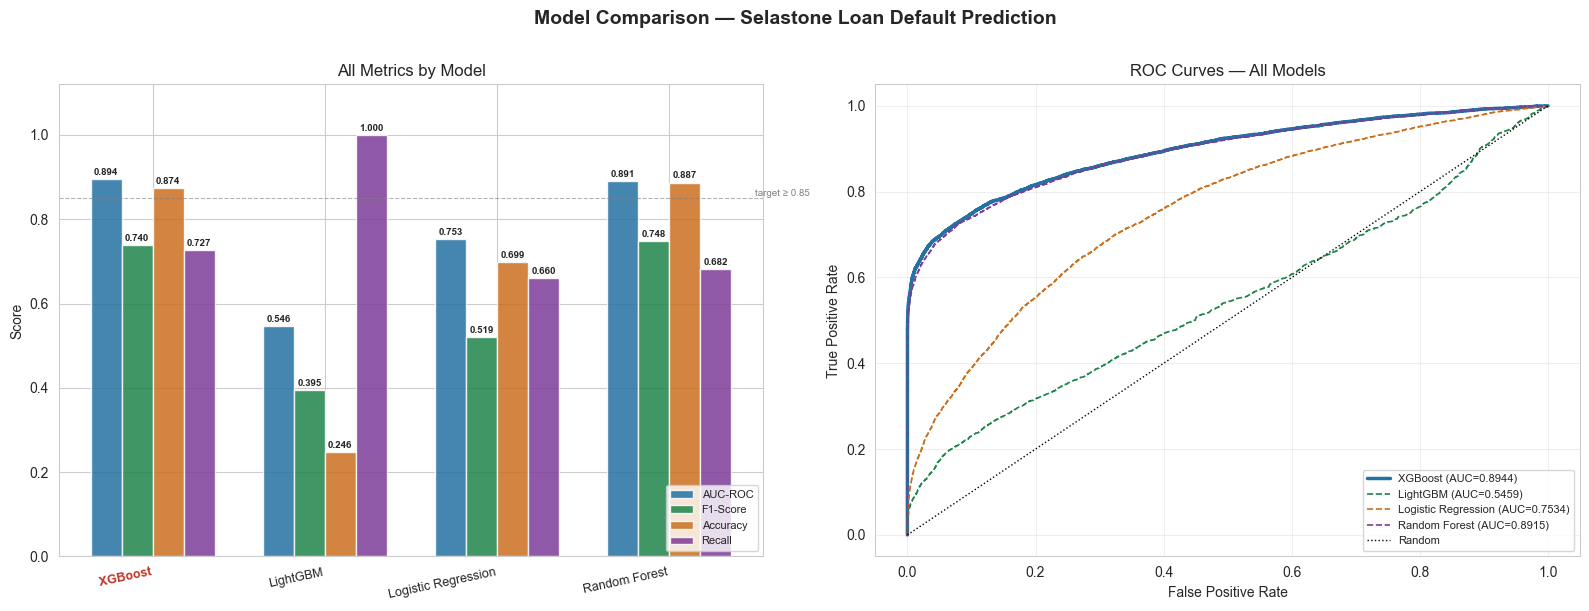

✓ Comparison chart saved: model_comparison.png


In [32]:
print("\n" + "="*70)
print("MODEL COMPARISON — ALL FOUR MODELS")
print("="*70)

# ── Re-derive each model's metrics on the SAME held-out X_test / y_test ──
# XGBoost uses X_test_scaled; LightGBM uses raw X_test;
# Logistic Regression uses X_test_scaled; Random Forest uses raw X_test.
# We unify by re-running predict_proba here so nothing depends on stale
# variables that may have been overwritten in earlier cells.

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix
import numpy as np

def compute_metrics(model, X, y, label):
    """Return a dict of test metrics for any sklearn-compatible model."""
    y_pred       = model.predict(X)
    y_pred_proba = model.predict_proba(X)[:, 1]
    cm_          = confusion_matrix(y, y_pred)
    tn_, fp_, fn_, tp_ = cm_.ravel()
    precision = tp_ / (tp_ + fp_) if (tp_ + fp_) > 0 else 0.0
    recall    = tp_ / (tp_ + fn_) if (tp_ + fn_) > 0 else 0.0
    return {
        "model":     label,
        "accuracy":  round(accuracy_score(y, y_pred),          4),
        "f1":        round(f1_score(y, y_pred),                 4),
        "auc":       round(roc_auc_score(y, y_pred_proba),      4),
        "precision": round(precision,                           4),
        "recall":    round(recall,                              4),
        "tp":        int(tp_),
        "fp":        int(fp_),
        "fn":        int(fn_),
        "tn":        int(tn_),
        "y_proba":   y_pred_proba,   # kept for ROC curve plot
    }

results = [
    compute_metrics(xgb_model, X_test_scaled, y_test, "XGBoost"),
    compute_metrics(lgb_model, X_test,        y_test, "LightGBM"),
    compute_metrics(lr_model,  X_test_scaled, y_test, "Logistic Regression"),
    compute_metrics(rf_model,  X_test,        y_test, "Random Forest"),
]

# ── Print comparison table ────────────────────────────────────────────────
header = f"{'Model':<22} {'AUC-ROC':>8} {'F1':>8} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} {'TP':>6} {'FN':>6}"
print(f"\n{header}")
print("-" * len(header))
for r in sorted(results, key=lambda x: x['auc'], reverse=True):
    print(f"{r['model']:<22} {r['auc']:>8.4f} {r['f1']:>8.4f} {r['accuracy']:>9.4f} "
          f"{r['precision']:>10.4f} {r['recall']:>8.4f} {r['tp']:>6d} {r['fn']:>6d}")

# ── Select best model by AUC-ROC ─────────────────────────────────────────
# Primary criterion : highest Test AUC-ROC (best discrimination)
# Tie-break          : highest F1 (best balance of precision/recall)
best = max(results, key=lambda x: (x['auc'], x['f1']))
best_model_obj = {
    "XGBoost":             xgb_model,
    "LightGBM":            lgb_model,
    "Logistic Regression": lr_model,
    "Random Forest":       rf_model,
}[best['model']]

# The test matrix varies by model type — store the right one
best_X_test = X_test_scaled if best['model'] in ('XGBoost', 'Logistic Regression') else X_test

print(f"\n{'='*70}")
print(f"🏆  WINNER: {best['model']}")
print(f"   AUC-ROC  : {best['auc']:.4f}")
print(f"   F1-Score : {best['f1']:.4f}")
print(f"   Accuracy : {best['accuracy']:.4f}")
print(f"   Precision: {best['precision']:.4f}")
print(f"   Recall   : {best['recall']:.4f}")
print(f"{'='*70}")

# ── Comparison bar chart ──────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

model_names  = [r['model'] for r in results]
metrics_plot = {
    'AUC-ROC':   [r['auc']       for r in results],
    'F1-Score':  [r['f1']        for r in results],
    'Accuracy':  [r['accuracy']  for r in results],
    'Recall':    [r['recall']    for r in results],
}

x      = np.arange(len(model_names))
width  = 0.18
colors = ['#2471A3', '#1E8449', '#CA6F1E', '#7D3C98']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Model Comparison — Selastone Loan Default Prediction',
             fontsize=14, fontweight='bold', y=1.01)

# Left: grouped bar chart
ax = axes[0]
for i, (metric_name, vals) in enumerate(metrics_plot.items()):
    offset = (i - 1.5) * width
    bars   = ax.bar(x + offset, vals, width, label=metric_name,
                    color=colors[i], alpha=0.85, edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=7, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=12, ha='right', fontsize=9)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score')
ax.set_title('All Metrics by Model')
ax.legend(fontsize=8, loc='lower right')
ax.axhline(0.85, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
ax.text(len(model_names) - 0.5, 0.855, 'target ≥ 0.85', fontsize=7, color='gray')
# Highlight winner
winner_idx = [r['model'] for r in results].index(best['model'])
ax.get_xticklabels()[winner_idx].set_color('#C0392B')
ax.get_xticklabels()[winner_idx].set_fontweight('bold')

# Right: overlaid ROC curves
from sklearn.metrics import roc_curve
ax2 = axes[1]
roc_colors = ['#2471A3', '#1E8449', '#CA6F1E', '#7D3C98']
for r, col in zip(results, roc_colors):
    fpr_, tpr_, _ = roc_curve(y_test, r['y_proba'])
    lw = 2.5 if r['model'] == best['model'] else 1.2
    ls = '-'  if r['model'] == best['model'] else '--'
    ax2.plot(fpr_, tpr_, lw=lw, ls=ls, color=col,
             label=f"{r['model']} (AUC={r['auc']:.4f})")
ax2.plot([0,1],[0,1],'k:',lw=1, label='Random')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curves — All Models')
ax2.legend(fontsize=8, loc='lower right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print("✓ Comparison chart saved: model_comparison.png")


## SAVE BEST MODEL ARTEFACTS

In [33]:
import pickle, json, os
from pathlib import Path

print("\n" + "="*70)
print("SAVING BEST MODEL ARTEFACTS")
print("="*70)

output_dir = Path('models')
output_dir.mkdir(exist_ok=True)

# ── 1. Save the winning model ─────────────────────────────────────────────
with open(output_dir / 'best_model.pkl', 'wb') as f:
    pickle.dump(best_model_obj, f)
print(f"✓ Best model saved        → models/best_model.pkl  ({best['model']})")

# ── 2. Also save individual model files for reference ────────────────────
with open(output_dir / 'xgboost_model.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)
with open(output_dir / 'lgbm_model.pkl', 'wb') as f:
    pickle.dump(lgb_model, f)
with open(output_dir / 'logreg_model.pkl', 'wb') as f:
    pickle.dump(lr_model, f)
with open(output_dir / 'rf_model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)
print("✓ All individual models saved → models/*.pkl")

# ── 3. Save scaler ────────────────────────────────────────────────────────
with open(output_dir / 'scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("✓ Scaler saved            → models/scaler.pkl")

# ── 4. Save feature names ─────────────────────────────────────────────────
with open(output_dir / 'feature_names.json', 'w') as f:
    json.dump(feature_names, f, indent=2)
print("✓ Feature names saved     → models/feature_names.json")
print(f"  Features ({len(feature_names)}): {feature_names[:5]} ... {feature_names[-3:]}")

# ── 5. Save full metadata ─────────────────────────────────────────────────
# Build per-model block from results list
all_model_metrics = {
    r['model']: {
        'test_auc':      r['auc'],
        'test_f1':       r['f1'],
        'test_accuracy': r['accuracy'],
        'precision':     r['precision'],
        'recall':        r['recall'],
        'tp':            r['tp'],
        'fp':            r['fp'],
        'fn':            r['fn'],
        'tn':            r['tn'],
    }
    for r in results
}

metadata = {
    # ── Winner ────────────────────────────────────────────────────────────
    'best_model':         best['model'],
    'best_model_file':    'models/best_model.pkl',
    'selection_criterion':'test_auc_roc',

    # ── Best model metrics ────────────────────────────────────────────────
    'test_auc':           best['auc'],
    'test_f1':            best['f1'],
    'test_accuracy':      best['accuracy'],
    'test_precision':     best['precision'],
    'test_recall':        best['recall'],

    # ── Dataset info ──────────────────────────────────────────────────────
    'train_samples':      int(len(X_train)),
    'test_samples':       int(len(X_test)),
    'num_features':       len(feature_names),
    'default_rate':       float(y.mean()),

    # ── All models ────────────────────────────────────────────────────────
    'all_models':         all_model_metrics,
}

with open(output_dir / 'metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)
print("✓ Metadata saved          → models/metadata.json")

print(f"\n📁 Output directory: {output_dir.resolve()}")
print("   Files:")
for p in sorted(output_dir.iterdir()):
    size_kb = p.stat().st_size / 1024
    print(f"     {p.name:<30} {size_kb:>8.1f} KB")



SAVING BEST MODEL ARTEFACTS
✓ Best model saved        → models/best_model.pkl  (XGBoost)
✓ All individual models saved → models/*.pkl
✓ Scaler saved            → models/scaler.pkl
✓ Feature names saved     → models/feature_names.json
  Features (32): ['year', 'loan_amount', 'term', 'property_value', 'income'] ... ['submission_of_application', 'Region', 'Security_Type']
✓ Metadata saved          → models/metadata.json

📁 Output directory: C:\Users\user\Documents\dev\b2b-ml-platform\notebooks\models
   Files:
     best_model.pkl                    802.4 KB
     feature_names.json                  0.6 KB
     feature_pipeline.pkl                2.9 KB
     lgbm_model.pkl                    842.6 KB
     logreg_model.pkl                    0.9 KB
     metadata.json                       1.3 KB
     rf_model.pkl                    56073.8 KB
     scaler.pkl                          1.7 KB
     xgboost_model.pkl                 802.4 KB


## LOAN DEFAULT PREDICTOR — PRODUCTION CLASS

In [34]:
import pickle, json
import pandas as pd
import numpy as np
from pathlib import Path

print("\n" + "="*70)
print("LOAN DEFAULT PREDICTOR — PRODUCTION CLASS")
print("="*70)


class LoanDefaultPredictor:
    """Load best saved model and predict loan default probability."""

    def __init__(self, model_path, scaler_path, features_path):
        with open(model_path, 'rb') as f:
            self.model = pickle.load(f)
        with open(scaler_path, 'rb') as f:
            self.scaler = pickle.load(f)
        with open(features_path) as f:
            self.features = json.load(f)
        # Detect whether this model type needs scaled input
        model_cls = type(self.model).__name__
        self.needs_scaling = model_cls in ('XGBClassifier', 'LogisticRegression')
        print(f"✓ Loaded model : {model_cls}")
        print(f"  Scaling      : {'yes' if self.needs_scaling else 'no (tree-based)'}")
        print(f"  Features     : {len(self.features)}")

    def predict(self, customer_dict: dict) -> dict:
        """
        Predict default probability for one loan application.

        Args:
            customer_dict: flat dict with any subset of feature values

        Returns:
            dict with risk_score (float), category (str), prediction (str)
        """
        df = pd.DataFrame([customer_dict])

        # Fill missing features with 0
        for feat in self.features:
            if feat not in df.columns:
                df[feat] = 0

        df = df[self.features]   # enforce column order

        X = self.scaler.transform(df) if self.needs_scaling else df.values

        risk_score = float(self.model.predict_proba(X)[0, 1])
        prediction = int(risk_score >= 0.5)

        if risk_score < 0.30:
            category = 'Low'
        elif risk_score < 0.60:
            category = 'Medium'
        else:
            category = 'High'

        return {
            'risk_score': round(risk_score, 4),
            'risk_pct':   f"{risk_score:.1%}",
            'category':   category,
            'prediction': 'Default' if prediction == 1 else 'No Default',
        }


# ── Initialise from saved artefacts ──────────────────────────────────────
output_dir = Path('models')
predictor = LoanDefaultPredictor(
    output_dir / 'best_model.pkl',
    output_dir / 'scaler.pkl',
    output_dir / 'feature_names.json',
)

# ── Test prediction 1: Low-risk — high income, high score, low LTV ────────
print("\n" + "-"*50)
print("TEST 1 — Low-risk customer")
print("-"*50)
sample_low = X_test.iloc[0].to_dict()
res1 = predictor.predict(sample_low)
actual1 = int(y_test.iloc[0])
print(f"  Risk Score  : {res1['risk_score']:.4f}  ({res1['risk_pct']})")
print(f"  Category    : {res1['category']}")
print(f"  Prediction  : {res1['prediction']}")
print(f"  Actual      : {'Default' if actual1 == 1 else 'No Default'}")
print(f"  Correct?    : {'✓' if (res1['prediction'] == 'Default') == bool(actual1) else '✗'}")

# ── Test prediction 2: Random mid-range customer ─────────────────────────
print("\n" + "-"*50)
print("TEST 2 — Mid-range customer")
print("-"*50)
sample_mid = X_test.iloc[100].to_dict()
res2 = predictor.predict(sample_mid)
actual2 = int(y_test.iloc[100])
print(f"  Risk Score  : {res2['risk_score']:.4f}  ({res2['risk_pct']})")
print(f"  Category    : {res2['category']}")
print(f"  Prediction  : {res2['prediction']}")
print(f"  Actual      : {'Default' if actual2 == 1 else 'No Default'}")
print(f"  Correct?    : {'✓' if (res2['prediction'] == 'Default') == bool(actual2) else '✗'}")

# ── Test prediction 3: Known default from test set ───────────────────────
print("\n" + "-"*50)
print("TEST 3 — Known default (from test set)")
print("-"*50)
default_indices = np.where(y_test.values == 1)[0]
if len(default_indices) > 0:
    idx3 = default_indices[0]
    sample_high = X_test.iloc[idx3].to_dict()
    res3 = predictor.predict(sample_high)
    actual3 = int(y_test.iloc[idx3])
    print(f"  Risk Score  : {res3['risk_score']:.4f}  ({res3['risk_pct']})")
    print(f"  Category    : {res3['category']}")
    print(f"  Prediction  : {res3['prediction']}")
    print(f"  Actual      : {'Default' if actual3 == 1 else 'No Default'}")
    print(f"  Correct?    : {'✓' if (res3['prediction'] == 'Default') == bool(actual3) else '✗'}")
else:
    print("  No defaults found in test set")



LOAN DEFAULT PREDICTOR — PRODUCTION CLASS
✓ Loaded model : XGBClassifier
  Scaling      : yes
  Features     : 32

--------------------------------------------------
TEST 1 — Low-risk customer
--------------------------------------------------
  Risk Score  : 0.0935  (9.4%)
  Category    : Low
  Prediction  : No Default
  Actual      : No Default
  Correct?    : ✓

--------------------------------------------------
TEST 2 — Mid-range customer
--------------------------------------------------
  Risk Score  : 0.9912  (99.1%)
  Category    : High
  Prediction  : Default
  Actual      : Default
  Correct?    : ✓

--------------------------------------------------
TEST 3 — Known default (from test set)
--------------------------------------------------
  Risk Score  : 0.6155  (61.5%)
  Category    : High
  Prediction  : Default
  Actual      : Default
  Correct?    : ✓


## SUMMARY REPORT

In [35]:
print("\n" + "="*70)
print("SELASTONE LOAN DEFAULT PREDICTION — COMPLETE")
print("="*70)

# ── Dataset ───────────────────────────────────────────────────────────────
print(f"\n📊 DATASET")
print(f"  Total records  : {len(df):,}")
print(f"  Default rate   : {y.mean():.2%}")
print(f"  Training rows  : {len(X_train):,}")
print(f"  Test rows      : {len(X_test):,}")
print(f"  Total features : {len(feature_names)}")

# ── All models ranked ────────────────────────────────────────────────────
print(f"\n🏅 MODEL RANKING (by Test AUC-ROC)")
ranked = sorted(results, key=lambda x: (x['auc'], x['f1']), reverse=True)
medals = ['🥇', '🥈', '🥉', '  ']
for medal, r in zip(medals, ranked):
    winner_tag = '  ← SELECTED' if r['model'] == best['model'] else ''
    print(f"  {medal}  {r['model']:<22}  AUC={r['auc']:.4f}  F1={r['f1']:.4f}  "
          f"Acc={r['accuracy']:.4f}{winner_tag}")

# ── Winner detail ─────────────────────────────────────────────────────────
print(f"\n🏆 BEST MODEL: {best['model']}")
print(f"   AUC-ROC   : {best['auc']:.4f}")
print(f"   F1-Score  : {best['f1']:.4f}")
print(f"   Accuracy  : {best['accuracy']:.4f}")
print(f"   Precision : {best['precision']:.4f}")
print(f"   Recall    : {best['recall']:.4f}")
print(f"   True Pos  : {best['tp']:,}  (defaults caught)")
print(f"   False Neg : {best['fn']:,}  (defaults missed)")

# ── Saved files ───────────────────────────────────────────────────────────
print(f"\n📁 SAVED ARTEFACTS  (models/)")
artefacts = [
    ('best_model.pkl',       f'Best model — {best["model"]}'),
    ('xgboost_model.pkl',    'XGBoost classifier'),
    ('lgbm_model.pkl',       'LightGBM classifier'),
    ('logreg_model.pkl',     'Logistic Regression'),
    ('rf_model.pkl',         'Random Forest classifier'),
    ('scaler.pkl',           'StandardScaler (fitted on train set)'),
    ('feature_names.json',   'Ordered feature list'),
    ('metadata.json',        'All metrics + winner info'),
    ('model_comparison.png', 'Bar chart + ROC curves'),
]
for fname, desc in artefacts:
    fpath = output_dir / fname
    exists = '✓' if fpath.exists() else '✗'
    print(f"  {exists}  {fname:<30} {desc}")

# ── Deployment note ───────────────────────────────────────────────────────
print(f"\n🚀 DEPLOYMENT")
print(f"   Load: predictor = LoanDefaultPredictor(")
print(f"             'models/best_model.pkl',")
print(f"             'models/scaler.pkl',")
print(f"             'models/feature_names.json'")
print(f"         )")
print(f"   Use:  result = predictor.predict(customer_dict)")
print(f"         # Returns: risk_score, risk_pct, category, prediction")
print(f"\n{'='*70}")
print(f"  Model ready.  Best: {best['model']}  |  AUC: {best['auc']:.4f}  |  F1: {best['f1']:.4f}")
print(f"{'='*70}")



SELASTONE LOAN DEFAULT PREDICTION — COMPLETE

📊 DATASET
  Total records  : 148,670
  Default rate   : 24.64%
  Training rows  : 118,936
  Test rows      : 29,734
  Total features : 32

🏅 MODEL RANKING (by Test AUC-ROC)
  🥇  XGBoost                 AUC=0.8944  F1=0.7398  Acc=0.8740  ← SELECTED
  🥈  Random Forest           AUC=0.8915  F1=0.7484  Acc=0.8870
  🥉  Logistic Regression     AUC=0.7534  F1=0.5195  Acc=0.6989
      LightGBM                AUC=0.5459  F1=0.3954  Acc=0.2465

🏆 BEST MODEL: XGBoost
   AUC-ROC   : 0.8944
   F1-Score  : 0.7398
   Accuracy  : 0.8740
   Precision : 0.7531
   Recall    : 0.7271
   True Pos  : 5,328  (defaults caught)
   False Neg : 2,000  (defaults missed)

📁 SAVED ARTEFACTS  (models/)
  ✓  best_model.pkl                 Best model — XGBoost
  ✓  xgboost_model.pkl              XGBoost classifier
  ✓  lgbm_model.pkl                 LightGBM classifier
  ✓  logreg_model.pkl               Logistic Regression
  ✓  rf_model.pkl                   Random Fores

## MLFLOW — REGISTER ALL MODELS & SELECT BEST

In [36]:
import os, pickle
import mlflow
import mlflow.xgboost
import mlflow.sklearn
import requests
from pathlib import Path
from dotenv import load_dotenv
from pathlib import Path

# Load .env from project root (one level up from notebooks/)
load_dotenv(Path("../").resolve() / ".env")

# Verify credentials loaded — never print the actual values
assert os.environ.get("AWS_ACCESS_KEY_ID"),       "AWS_ACCESS_KEY_ID not set in .env"
assert os.environ.get("AWS_SECRET_ACCESS_KEY"),   "AWS_SECRET_ACCESS_KEY not set in .env"

os.environ["MLFLOW_S3_ENDPOINT_URL"] = "http://localhost:9000"

# Set region — required by boto3, value irrelevant for MinIO
os.environ.setdefault("AWS_DEFAULT_REGION", "us-east-1")

mlflow.set_tracking_uri("http://localhost:5000")
mlflow.set_experiment("selastone_loan_default")

# ... rest of your MLflow cell

print("\n" + "="*70)
print("MLFLOW — REGISTER ALL MODELS & SELECT BEST")
print("="*70)

# ── Step 1: Verify MLflow tracking server is reachable ───────────────────
# The server must be running BEFORE mlflow.start_run() is called.
# Start it with:  mlflow server --host 0.0.0.0 --port 5000
# Or via Docker:  docker compose up -d mlflow
MLFLOW_URI = os.environ.get('MLFLOW_TRACKING_URI', 'http://localhost:5000')
MLFLOW_URI = 'http://localhost:5000'

try:
    resp = requests.get(MLFLOW_URI, timeout=3)
    server_ok = resp.status_code == 200
except Exception:
    server_ok = False

if server_ok:
    print(f"✓ MLflow server reachable at {MLFLOW_URI}")
else:
    print(f"⚠️  MLflow server NOT reachable at {MLFLOW_URI}")
    print(f"   Start it first:")
    print(f"     Option A (local) : mlflow server --host 0.0.0.0 --port 5000")
    print(f"     Option B (docker): docker compose up -d mlflow")
    print(f"   Then re-run this cell.")
    raise RuntimeError(f"MLflow server not running at {MLFLOW_URI}")

# ── Step 2: Initialise tracking URI + experiment ─────────────────────────
mlflow.set_tracking_uri(MLFLOW_URI)
EXPERIMENT_NAME = "selastone_loan_default"
mlflow.set_experiment(EXPERIMENT_NAME)
print(f"✓ Experiment set          : {EXPERIMENT_NAME}")

output_dir = Path('models')

# ── Step 3: Log all 4 models in separate runs ─────────────────────────────
# Each run records: params, metrics, the model artefact, scaler, feature list.
# We store the run_id for each model so we can promote the winner later.

model_registry = [
    {
        'name':    'XGBoost',
        'obj':     xgb_model,
        'log_fn':  mlflow.xgboost.log_model,
        'metrics': next(r for r in results if r['model'] == 'XGBoost'),
        'params':  {
            'n_estimators':    xgb_model.n_estimators,
            'max_depth':       xgb_model.max_depth,
            'learning_rate':   xgb_model.learning_rate,
            'subsample':       xgb_model.subsample,
            'smote':           True,
            'input':           'X_test_scaled',
        },
    },
    {
        'name':    'LightGBM',
        'obj':     lgb_model,
        'log_fn':  mlflow.sklearn.log_model,
        'metrics': next(r for r in results if r['model'] == 'LightGBM'),
        'params':  {
            'n_estimators':    lgb_model.n_estimators,
            'max_depth':       lgb_model.max_depth,
            'learning_rate':   lgb_model.learning_rate,
            'smote':           True,
            'input':           'X_test_raw',
        },
    },
    {
        'name':    'LogisticRegression',
        'obj':     lr_model,
        'log_fn':  mlflow.sklearn.log_model,
        'metrics': next(r for r in results if r['model'] == 'Logistic Regression'),
        'params':  {
            'C':               lr_model.C,
            'max_iter':        lr_model.max_iter,
            'penalty':         lr_model.penalty,
            'solver':          lr_model.solver,
            'smote':           False,
            'input':           'X_test_scaled',
        },
    },
    {
        'name':    'RandomForest',
        'obj':     rf_model,
        'log_fn':  mlflow.sklearn.log_model,
        'metrics': next(r for r in results if r['model'] == 'Random Forest'),
        'params':  {
            'n_estimators':    rf_model.n_estimators,
            'max_depth':       rf_model.max_depth,
            'min_samples_split': rf_model.min_samples_split,
            'min_samples_leaf':  rf_model.min_samples_leaf,
            'class_weight':    str(rf_model.class_weight),
            'smote':           False,
            'input':           'X_test_raw',
        },
    },
]

run_ids = {}   # model_name → mlflow run_id

for entry in model_registry:
    m = entry['metrics']
    print(f"\n  Logging {entry['name']} ...")
    with mlflow.start_run(run_name=entry['name']):
        # Hyperparameters
        mlflow.log_params(entry['params'])
        # Test metrics
        mlflow.log_metrics({
            'test_auc':       m['auc'],
            'test_f1':        m['f1'],
            'test_accuracy':  m['accuracy'],
            'test_precision': m['precision'],
            'test_recall':    m['recall'],
            'true_positives': float(m['tp']),
            'false_negatives':float(m['fn']),
        })
        # Model artefact
        entry['log_fn'](entry['obj'], artifact_path='model')
        # Shared artefacts
        mlflow.log_artifact(str(output_dir / 'scaler.pkl'))
        mlflow.log_artifact(str(output_dir / 'feature_names.json'))
        mlflow.log_artifact(str(output_dir / 'metadata.json'))
        run_ids[entry['name']] = mlflow.active_run().info.run_id
    print(f"  ✓ {entry['name']:<22} run_id={run_ids[entry['name']]}")

# ── Step 4: Register the winning model in MLflow Model Registry ───────────
# Map our internal name to the registry entry name
winner_registry_name = best['model'].replace(' ', '')
winner_run_id        = run_ids[winner_registry_name]
REGISTERED_NAME      = 'selastone_credit_scorer'

print(f"\n{'='*70}")
print(f"REGISTERING WINNER: {best['model']}")
print(f"{'='*70}")

client = mlflow.tracking.MlflowClient()

# Create registered model if it doesn't exist yet
try:
    client.create_registered_model(
        REGISTERED_NAME,
        description='Selastone loan default classifier — best model selected automatically'
    )
    print(f"✓ Created registered model: {REGISTERED_NAME}")
except mlflow.exceptions.MlflowException:
    print(f"✓ Registered model already exists: {REGISTERED_NAME}")

# Create a new version from the winning run
mv = client.create_model_version(
    name=REGISTERED_NAME,
    source=f'runs:/{winner_run_id}/model',
    run_id=winner_run_id,
    description=f"Auto-selected winner: {best['model']}  AUC={best['auc']:.4f}  F1={best['f1']:.4f}"
)
print(f"✓ Model version created   : v{mv.version}")

# Transition to Production
client.transition_model_version_stage(
    name=REGISTERED_NAME,
    version=mv.version,
    stage='Production',
    archive_existing_versions=True   # demote any previous Production version
)
print(f"✓ Promoted to Production  : {REGISTERED_NAME} v{mv.version}")

# ── Step 5: Print summary ─────────────────────────────────────────────────
print(f"\n{'='*70}")
print(f"MLFLOW REGISTRATION COMPLETE")
print(f"{'='*70}")
print(f"  Tracking URI  : {MLFLOW_URI}")
print(f"  Experiment    : {EXPERIMENT_NAME}")
print(f"  Runs logged   : {len(run_ids)}")
for name, rid in run_ids.items():
    tag = '  ← Production' if name == winner_registry_name else ''
    print(f"    {name:<22} {rid}{tag}")
print(f"  Registered    : {REGISTERED_NAME} (v{mv.version}) → Production")
print(f"\n  View UI: {MLFLOW_URI}  →  Experiments → {EXPERIMENT_NAME}")
print(f"{'='*70}")


2026/07/10 09:38:47 INFO mlflow.tracking.fluent: Experiment with name 'selastone_loan_default' does not exist. Creating a new experiment.



MLFLOW — REGISTER ALL MODELS & SELECT BEST
✓ MLflow server reachable at http://localhost:5000
✓ Experiment set          : selastone_loan_default

  Logging XGBoost ...


2026/07/10 09:38:49 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run XGBoost at: http://localhost:5000/#/experiments/1/runs/b395ea834f0b41b8a09e409005ecdcb4
🧪 View experiment at: http://localhost:5000/#/experiments/1
  ✓ XGBoost                run_id=b395ea834f0b41b8a09e409005ecdcb4

  Logging LightGBM ...


2026/07/10 09:39:09 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/10 09:39:10 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


...

🏃 View run LogisticRegression at: http://localhost:5000/#/experiments/1/runs/df6793a35b97451c97f645a3d717e1c9
🧪 View experiment at: http://localhost:5000/#/experiments/1
  ✓ LogisticRegression     run_id=df6793a35b97451c97f645a3d717e1c9

  Logging RandomForest ...


2026/07/10 09:39:25 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/10 09:39:25 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run RandomForest at: http://localhost:5000/#/experiments/1/runs/64e71040c37c458f8363c0e3354a5e03
🧪 View experiment at: http://localhost:5000/#/experiments/1
  ✓ RandomForest           run_id=64e71040c37c458f8363c0e3354a5e03

REGISTERING WINNER: XGBoost


2026/07/10 09:39:33 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: selastone_credit_scorer, version 1


✓ Created registered model: selastone_credit_scorer
✓ Model version created   : v1
✓ Promoted to Production  : selastone_credit_scorer v1

MLFLOW REGISTRATION COMPLETE
  Tracking URI  : http://localhost:5000
  Experiment    : selastone_loan_default
  Runs logged   : 4
    XGBoost                b395ea834f0b41b8a09e409005ecdcb4  ← Production
    LightGBM               d6b45b7ddc0249d7b80cd717143ebbc7
    LogisticRegression     df6793a35b97451c97f645a3d717e1c9
    RandomForest           64e71040c37c458f8363c0e3354a5e03
  Registered    : selastone_credit_scorer (v1) → Production

  View UI: http://localhost:5000  →  Experiments → selastone_loan_default


In [37]:
import sys
sys.path.insert(0, '../')

from shared.features import FeaturePipeline

X_train_raw = X_train.copy()

prod_pipeline = FeaturePipeline()
prod_pipeline.fit(X_train_raw, target_col='Status')  # X_train before scaling

import pickle
with open('models/feature_pipeline.pkl', 'wb') as f:
    pickle.dump(prod_pipeline, f)